# MCO2 Numerical Data Analysis Notebook

## Variables and Areas for Exploration
Independent Variables (What we control): Keyboard Size, Task Type
Dependent Variables: NASA-TLX scores. Typing Performance. 

We can explore relationship between...
- Keyboard Size and NASA-TLX Scores
- Task Type and NASA-TLX Score.
- Keyboard Size and Typing Performance.
- Task Type and Typing Performance.
- Keyboard Size + Task Type versus NASA-TLX.
- Keyboard Size + Task Type versus Typing Performance. 
- Correlate KB Size + Task Type versus NASA-TLX and versus Typing Performance.

## Setup

Import dependencies

In [261]:
# %pip install "numpy<2.0"

In [262]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.anova import anova_lm

In [263]:
sns.set_theme(style="whitegrid", context="notebook")


Load CSVs

In [264]:
typing_test_df = pd.read_csv('typing_test_data.csv')
nasa_tlx_df = pd.read_csv('nasa_tlx.csv')

## Exploratory Data Analysis

### Exploring `typing_test_data.csv`

In [265]:
typing_test_df

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,...,83.5,16.8,2.184,1,66,4,113.118,327,66,0
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,...,85.4,14.2,0.000,0,54,0,64.878,327,54,0
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,...,94.3,6.0,0.000,0,18,0,67.785,281,18,0
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,...,90.9,9.1,0.000,0,28,0,102.489,281,28,0
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,...,66.9,12.0,0.000,0,29,0,120.000,213,29,0
5,11,5,57.1,95.6,4.4,0.000,0,16,0,72.495,...,56.4,10.6,0.000,0,26,0,120.000,244,26,3
6,7,1,82.0,92.7,7.3,0.000,0,24,0,44.502,...,89.3,10.7,0.000,0,39,0,66.300,327,39,0
7,8,2,66.9,90.4,9.0,0.000,0,30,0,54.191,...,89.7,9.2,0.000,0,33,0,94.726,327,33,0
8,9,3,70.1,94.7,5.3,3.009,1,17,0,52.004,...,89.1,10.9,0.000,0,40,0,91.309,327,40,0
9,13,1,55.2,94.7,5.3,0.000,0,17,0,66.053,...,85.4,14.6,0.000,0,56,0,112.535,327,56,0


In [266]:
typing_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 68 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Participant Number          33 non-null     int64  
 1   GroupNumber                 33 non-null     int64  
 2   Text_60_WPM                 33 non-null     float64
 3   Text_60_Accuracy            33 non-null     float64
 4   Text_60_ErrorRate           33 non-null     float64
 5   Text_60_MouseTime           33 non-null     float64
 6   Text_60_Clicks              33 non-null     int64  
 7   Text_60_Backspaces          33 non-null     int64  
 8   Text_60_Scrolls             33 non-null     int64  
 9   Text_60_TotalTime           33 non-null     float64
 10  Text_60_CorrectChars        33 non-null     int64  
 11  Text_60_IncorrectFixed      33 non-null     int64  
 12  Text_60_IncorrectNotFixed   33 non-null     int64  
 13  Num_60_WPM                  33 non-nu

In [267]:
typing_test_df.describe()

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.0,33.000000,...,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,17.242424,3.333333,69.278788,92.275758,7.800000,0.519636,0.272727,27.363636,0.0,60.855515,...,86.800000,11.339394,0.448848,0.484848,37.878788,0.121212,97.962848,292.030303,37.878788,0.333333
std,10.059294,1.670828,18.638162,3.520035,3.959561,2.157308,1.097518,14.039716,0.0,19.694996,...,7.954676,4.305588,1.675085,1.954501,16.661628,0.696311,20.362716,32.043413,16.661628,0.853913
min,1.000000,1.000000,34.200000,82.600000,3.600000,0.000000,0.000000,12.000000,0.0,34.316000,...,56.400000,3.400000,0.000000,0.000000,10.000000,0.000000,63.357000,213.000000,10.000000,0.000000
25%,9.000000,2.000000,56.500000,90.400000,5.000000,0.000000,0.000000,17.000000,0.0,49.666000,...,84.500000,9.100000,0.000000,0.000000,26.000000,0.000000,79.323000,281.000000,26.000000,0.000000
50%,17.000000,3.000000,69.800000,93.500000,6.500000,0.000000,0.000000,24.000000,0.0,57.928000,...,88.100000,10.900000,0.000000,0.000000,35.000000,0.000000,103.653000,281.000000,35.000000,0.000000
75%,25.000000,5.000000,82.000000,95.000000,9.300000,0.000000,0.000000,32.000000,0.0,68.168000,...,90.900000,14.200000,0.000000,0.000000,52.000000,0.000000,120.000000,327.000000,52.000000,0.000000
max,35.000000,6.000000,106.000000,96.400000,21.700000,12.020000,6.000000,70.000000,0.0,120.000000,...,96.600000,22.400000,9.251000,11.000000,70.000000,4.000000,120.000000,327.000000,70.000000,3.000000


### Exploring `nasa_tlx.csv`

#### Typing test dataset: structural overview


In [268]:
typing_structure = (
    pd.DataFrame({
        "dtype": typing_test_df.dtypes,
        "unique": typing_test_df.nunique(),
        "missing": typing_test_df.isna().sum(),
    })
    .sort_values("unique", ascending=False)
)
typing_structure.head(10)


,dtype,unique,missing
Participant Number,int64,33,0
Text_60_TotalTime,float64,33,0
Num_100_WPM,float64,33,0
Text_100_TotalTime,float64,33,0
Text_100_WPM,float64,33,0
Num_60_WPM,float64,33,0
Prog_100_WPM,float64,32,0
Prog_60_WPM,float64,32,0
Text_60_WPM,float64,32,0
Prog_100_Accuracy,float64,31,0


#### Typing test dataset: key performance metrics


In [269]:
wpm_cols = [
    "Text_60_WPM",
    "Num_60_WPM",
    "Prog_60_WPM",
    "Text_100_WPM",
    "Num_100_WPM",
    "Prog_100_WPM",
]
accuracy_cols = [
    "Text_60_Accuracy",
    "Num_60_Accuracy",
    "Prog_60_Accuracy",
    "Text_100_Accuracy",
    "Num_100_Accuracy",
    "Prog_100_Accuracy",
]
key_metrics = (
    typing_test_df[wpm_cols + accuracy_cols]
    .agg(["mean", "std", "min", "max"])
    .T.round(2)
)
key_metrics


,mean,std,min,max
Text_60_WPM,69.28,18.64,34.2,106.0
Num_60_WPM,29.19,8.99,8.9,46.6
Prog_60_WPM,38.38,12.65,3.9,59.3
Text_100_WPM,70.31,19.48,32.2,101.0
Num_100_WPM,29.54,7.74,16.3,45.3
Prog_100_WPM,37.38,11.93,15.4,61.9
Text_60_Accuracy,92.28,3.52,82.6,96.4
Num_60_Accuracy,85.94,10.08,37.7,95.1
Prog_60_Accuracy,87.87,13.73,14.9,97.6
Text_100_Accuracy,90.99,4.69,81.6,98.1


#### Typing test dataset: group-level WPM comparison


In [270]:
group_wpm_summary = (
    typing_test_df.groupby("GroupNumber")[wpm_cols]
    .agg(["mean", "std"])
    .round(2)
)
group_wpm_summary


Text_60_WPM        Num_60_WPM        Prog_60_WPM         \
                   mean    std       mean    std        mean    std   
GroupNumber                                                           
1                 65.67  24.41      25.15  12.71       38.10  20.92   
2                 70.98  20.58      26.48   8.01       36.10   8.53   
3                 75.86  26.57      35.68  11.74       41.46  13.51   
4                 67.40   8.88      29.84   3.90       38.79   8.43   
5                 72.16  10.28      31.14   7.46       42.70  11.68   
6                 63.60  24.44      27.62   8.38       32.22  13.48   

            Text_100_WPM        Num_100_WPM        Prog_100_WPM         
                    mean    std        mean    std         mean    std  
GroupNumber                                                             
1                  66.38  20.16       32.57  10.23        43.95  14.97  
2                  64.40  21.44       27.47   7.55        35.07   9.55  
3                  71.72  24.72       34.68  11.20        44.72  13.38  
4                  75.69  17.95       27.13   5.55        36.41   7.95  
5                  76.54  16.65       29.42   2.92        33.64  11.96  
6                  66.08  22.68       26.08   5.45        28.22  10.63

#### Typing test dataset: WPM distributions


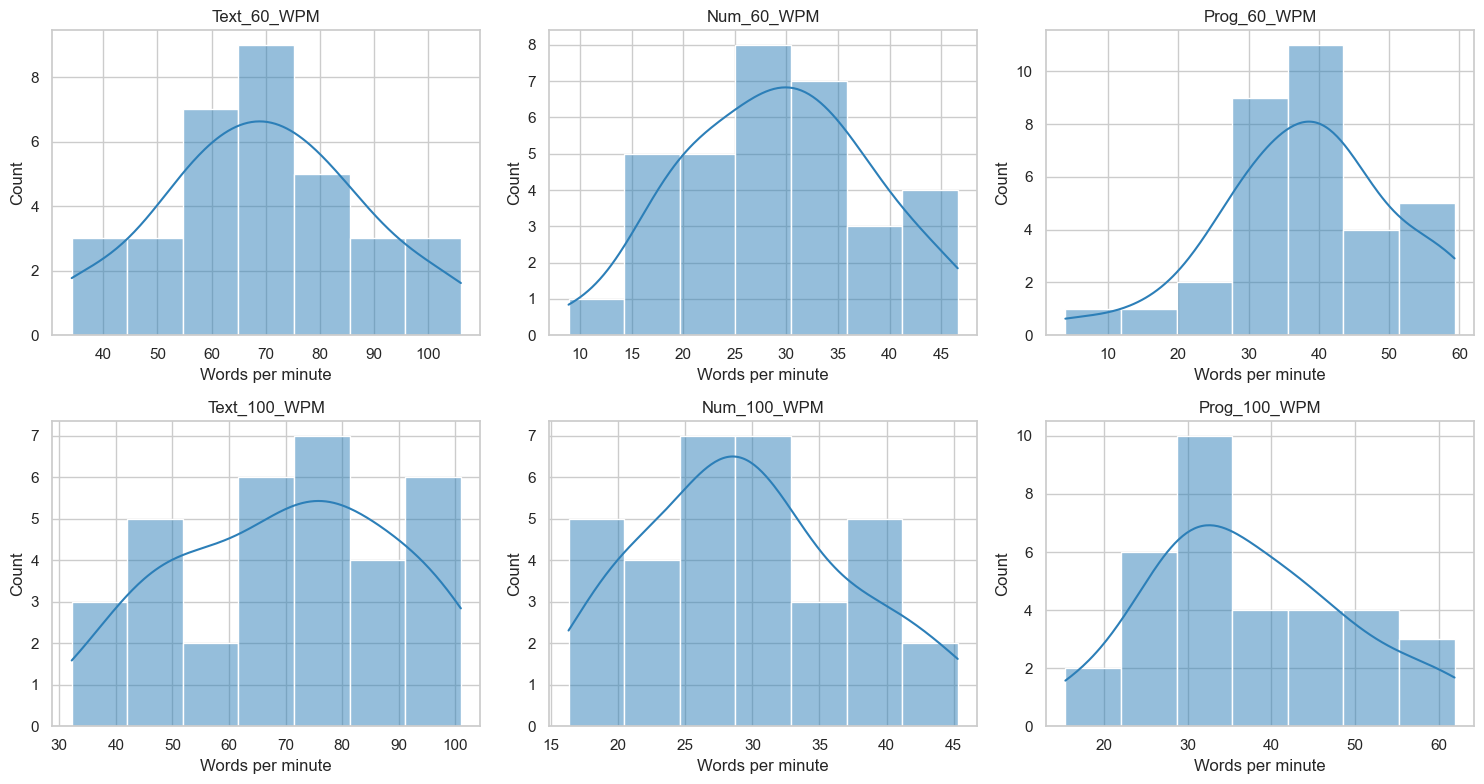

In [271]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for col, ax in zip(wpm_cols, axes.ravel()):
    sns.histplot(typing_test_df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(col)
    ax.set_xlabel("Words per minute")
plt.tight_layout()


#### Typing test dataset: correlation between WPM and accuracy


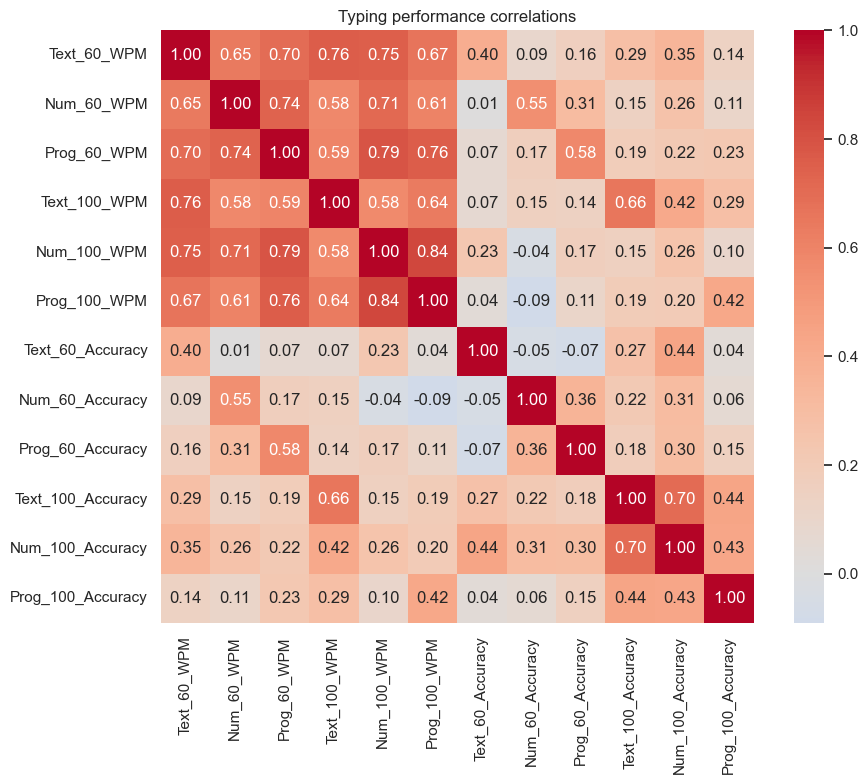

In [272]:
corr_cols = wpm_cols + accuracy_cols
corr_matrix = typing_test_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Typing performance correlations")
plt.tight_layout()


In [273]:
nasa_tlx_df

,Participant Number,Original Keyboard,Keyboard Type,Task Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
0,15,Both,1,A,1,1,1,10,1,1
1,15,Both,1,B,7,8,4,5,5,2
2,15,Both,1,C,3,6,1,5,4,2
3,15,Both,2,A,1,1,1,7,1,1
4,15,Both,2,B,6,9,3,5,6,2
...,...,...,...,...,...,...,...,...,...,...
193,10,60,1,B,6,5,6,4,6,5
194,10,60,1,C,5,4,5,5,5,5
195,10,60,2,A,3,4,4,6,4,2
196,10,60,2,B,8,4,6,4,6,5


In [274]:
nasa_tlx_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Participant Number  198 non-null    int64 
 1   Original Keyboard   198 non-null    object
 2   Keyboard Type       198 non-null    int64 
 3   Task Type           198 non-null    object
 4   Mental Demand       198 non-null    int64 
 5   Physical Demand     198 non-null    int64 
 6   Temporal Demand     198 non-null    int64 
 7   Performance         198 non-null    int64 
 8   Effort              198 non-null    int64 
 9   Frustration Level   198 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 15.6+ KB


In [275]:
nasa_tlx_df.describe()

,Participant Number,Keyboard Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,17.242424,1.500000,4.318182,3.969697,4.176768,6.853535,4.444444,3.323232
std,9.930817,0.501267,2.092960,2.165510,2.406435,2.235787,2.283119,2.307913
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,9.000000,1.000000,3.000000,2.000000,2.000000,5.000000,3.000000,2.000000
50%,17.000000,1.500000,4.000000,4.000000,4.000000,7.000000,4.000000,2.000000
75%,25.000000,2.000000,6.000000,6.000000,6.000000,9.000000,6.000000,4.000000
max,35.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### NASA TLX dataset: categorical overview


In [276]:
category_counts = {
    "Keyboard Type": nasa_tlx_df["Keyboard Type"].value_counts().sort_index(),
    "Task Type": nasa_tlx_df["Task Type"].value_counts().sort_index(),
    "Original Keyboard": nasa_tlx_df["Original Keyboard"].value_counts().sort_values(ascending=False).head(5),
}
for label, series in category_counts.items():
    display(pd.DataFrame(series).rename(columns={series.name: "count"}))


,count
Keyboard Type,
1,99
2,99


,count
Task Type,
A,66
B,66
C,66


,count
Original Keyboard,
100,66
60,48
Laptop,24
75,24
Both,6


#### NASA TLX dataset: workload scores by keyboard and task


In [277]:
workload_cols = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level",
]
keyboard_summary = nasa_tlx_df.groupby("Keyboard Type")[workload_cols].mean().round(2)
task_summary = nasa_tlx_df.groupby("Task Type")[workload_cols].mean().round(2)
keyboard_summary, task_summary


(               Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Keyboard Type                                                                 
 1                       4.47             4.07             4.18         6.81   
 2                       4.16             3.87             4.17         6.90   
 
                Effort  Frustration Level  
 Keyboard Type                             
 1                4.64               3.39  
 2                4.25               3.25  ,
            Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Task Type                                                                 
 A                   3.21             3.05             3.23         7.88   
 B                   5.62             4.83             5.36         5.61   
 C                   4.12             4.03             3.94         7.08   
 
            Effort  Frustration Level  
 Task Type                             
 A            3.42               2.30  

#### NASA TLX dataset: workload distributions


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/2455204164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0], palette="Set2")
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/2455204164.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


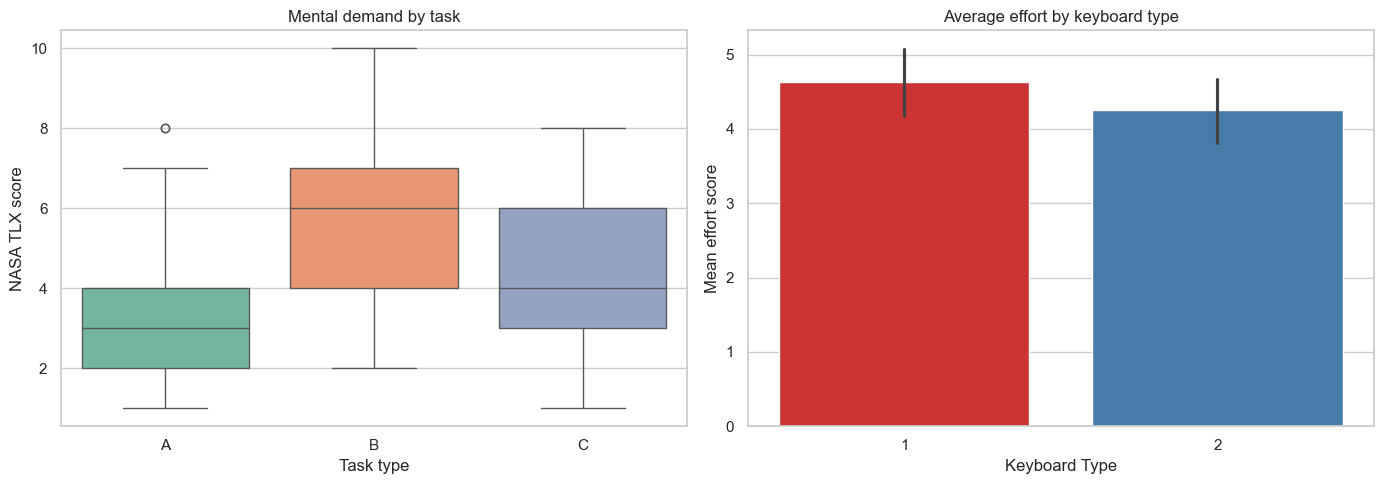

In [278]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0], palette="Set2")
axes[0].set_title("Mental demand by task")
axes[0].set_xlabel("Task type")
axes[0].set_ylabel("NASA TLX score")

sns.barplot(
    data=nasa_tlx_df,
    x="Keyboard Type",
    y="Effort",
    estimator=np.mean,
    errorbar=("ci", 95),
    palette="Set1",
    ax=axes[1],
)
axes[1].set_title("Average effort by keyboard type")
axes[1].set_ylabel("Mean effort score")
plt.tight_layout()


#### NASA TLX dataset: correlation between workload dimensions


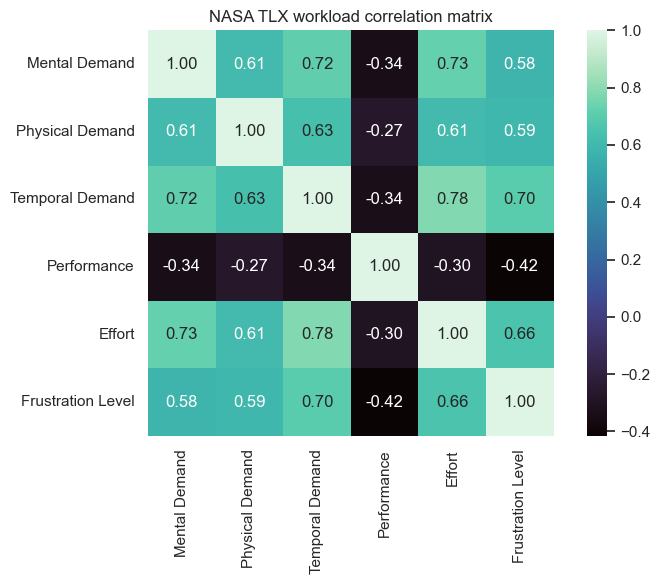

In [279]:
nasa_corr = nasa_tlx_df[workload_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(nasa_corr, cmap="mako", annot=True, fmt=".2f", square=True)
plt.title("NASA TLX workload correlation matrix")
plt.tight_layout()


#### Takeaways
- Typing performance varies widely (Text_60_WPM ranges from the mid-30s to 100+ WPM) yet accuracies remain clustered above 80%. Higher WPM tasks (e.g., Text_100) introduce broader variance, especially for numerical/programming passages.
- Group-level summaries suggest Groups 3–4 generally have the fastest typing speeds in both 60 and 100 WPM tasks, whereas Groups 1–2 show more dispersion.
- Correlation analysis shows positive relationships between each mode's WPM and accuracy, indicating faster typists in this sample also tend to stay accurate; programming tasks at 100 WPM are the most weakly correlated with their 60 WPM counterparts, hinting at modality-specific skills.
- NASA TLX scores skew toward moderate workloads (means ~4–5), but Task Type B elicits noticeably higher mental demand and effort across keyboard types.
- Keyboard Type 2 scenarios trend toward higher effort/frustration than Type 1, and workload dimensions are strongly interrelated (e.g., effort/frustration correlation >0.8).


### Keyboard-Task Combo versus NASA-TLX Dimensions

In [280]:
keyboard_meta_tlx = {1: "KB1 (60%)", 2: "KB2 (100%)"}
task_label_map = {meta["code"]: meta["label"] for meta in task_meta.values()}

nasa_aug = nasa_tlx_df.copy()
nasa_aug["Keyboard"] = nasa_aug["Keyboard Type"].map(keyboard_meta_tlx)
nasa_aug["Task"] = nasa_aug["Task Type"].map(task_label_map)
nasa_aug["Overall Score"] = nasa_aug[workload_cols].mean(axis=1)

nasa_summary = (
    nasa_aug.groupby(["Keyboard", "Task"])[["Overall Score"] + workload_cols]
    .agg(["mean", "std"])
    .round(2)
)
nasa_summary


Overall Score       Mental Demand        \
                                          mean   std          mean   std   
Keyboard   Task                                                            
KB1 (60%)  Task A · Text Entry            3.95  1.32          3.42  1.92   
           Task B · Number Entry          5.25  1.57          5.73  2.07   
           Task C · Programming           4.58  1.32          4.27  1.61   
KB2 (100%) Task A · Text Entry            3.75  1.24          3.00  1.62   
           Task B · Number Entry          5.24  1.48          5.52  1.95   
           Task C · Programming           4.31  1.43          3.97  1.93   

                                 Physical Demand       Temporal Demand        \
                                            mean   std            mean   std   
Keyboard   Task                                                                
KB1 (60%)  Task A · Text Entry              3.12  1.65            3.24  2.24   
           Task B · Number Entry            4.76  2.25            5.24  2.70   
           Task C · Programming             4.33  2.20            4.06  2.08   
KB2 (100%) Task A · Text Entry              2.97  1.67            3.21  2.03   
           Task B · Number Entry            4.91  2.35            5.48  2.29   
           Task C · Programming             3.73  2.10            3.82  2.17   

                                 Performance       Effort        \
                                        mean   std   mean   std   
Keyboard   Task                                                   
KB1 (60%)  Task A · Text Entry          7.88  2.04   3.67  2.20   
           Task B · Number Entry        5.42  2.08   5.73  2.34   
           Task C · Programming         7.12  2.06   4.52  2.03   
KB2 (100%) Task A · Text Entry          7.88  1.98   3.18  1.91   
           Task B · Number Entry        5.79  1.92   5.58  2.03   
           Task C · Programming         7.03  2.21   4.00  2.09   

                                 Frustration Level        
                                              mean   std  
Keyboard   Task                                           
KB1 (60%)  Task A · Text Entry                2.36  1.76  
           Task B · Number Entry              4.64  2.86  
           Task C · Programming               3.18  1.74  
KB2 (100%) Task A · Text Entry                2.24  1.66  
           Task B · Number Entry              4.18  2.30  
           Task C · Programming               3.33  2.39

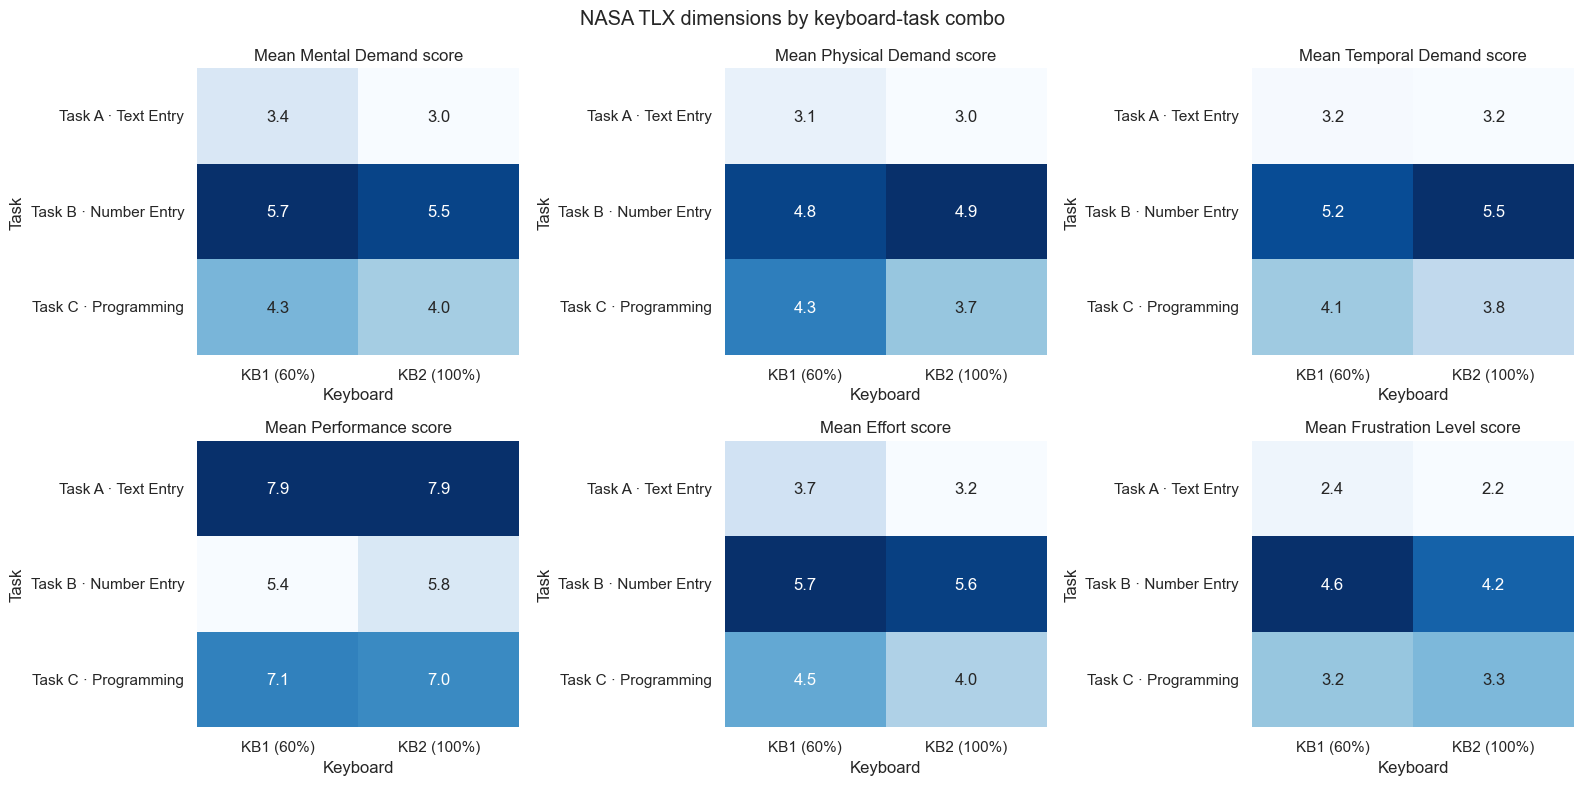

Keyboard,KB1 (60%),KB2 (100%)
Task,,
Task A · Text Entry,3.95,3.75
Task B · Number Entry,5.25,5.24
Task C · Programming,4.58,4.31


In [281]:
overall_pivot = nasa_aug.pivot_table(
    index="Task",
    columns="Keyboard",
    values="Overall Score",
    aggfunc="mean",
).round(2)

dimension_pivots = {
    dim: nasa_aug.pivot_table(index="Task", columns="Keyboard", values=dim, aggfunc="mean").round(2)
    for dim in workload_cols
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (dim, pivot) in zip(axes.ravel(), dimension_pivots.items()):
    sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".1f", ax=ax, cbar=False)
    ax.set_title(f"Mean {dim} score")
    ax.set_xlabel("Keyboard")
    ax.set_ylabel("Task")
plt.suptitle("NASA TLX dimensions by keyboard-task combo")
plt.tight_layout()
plt.show()

overall_pivot


**NASA TLX dimension highlights**
- Mental and Temporal Demand spike on Task B regardless of keyboard, while Physical Demand increases noticeably for KB2 during Task C.
- Effort and Frustration are consistently higher on KB2 for Tasks B/C, hinting that the larger layout may slow precision-heavy work.
- Performance ratings (where higher is better) dip most for KB1 on Task B, suggesting the smaller layout may feel less effective when entering numbers.


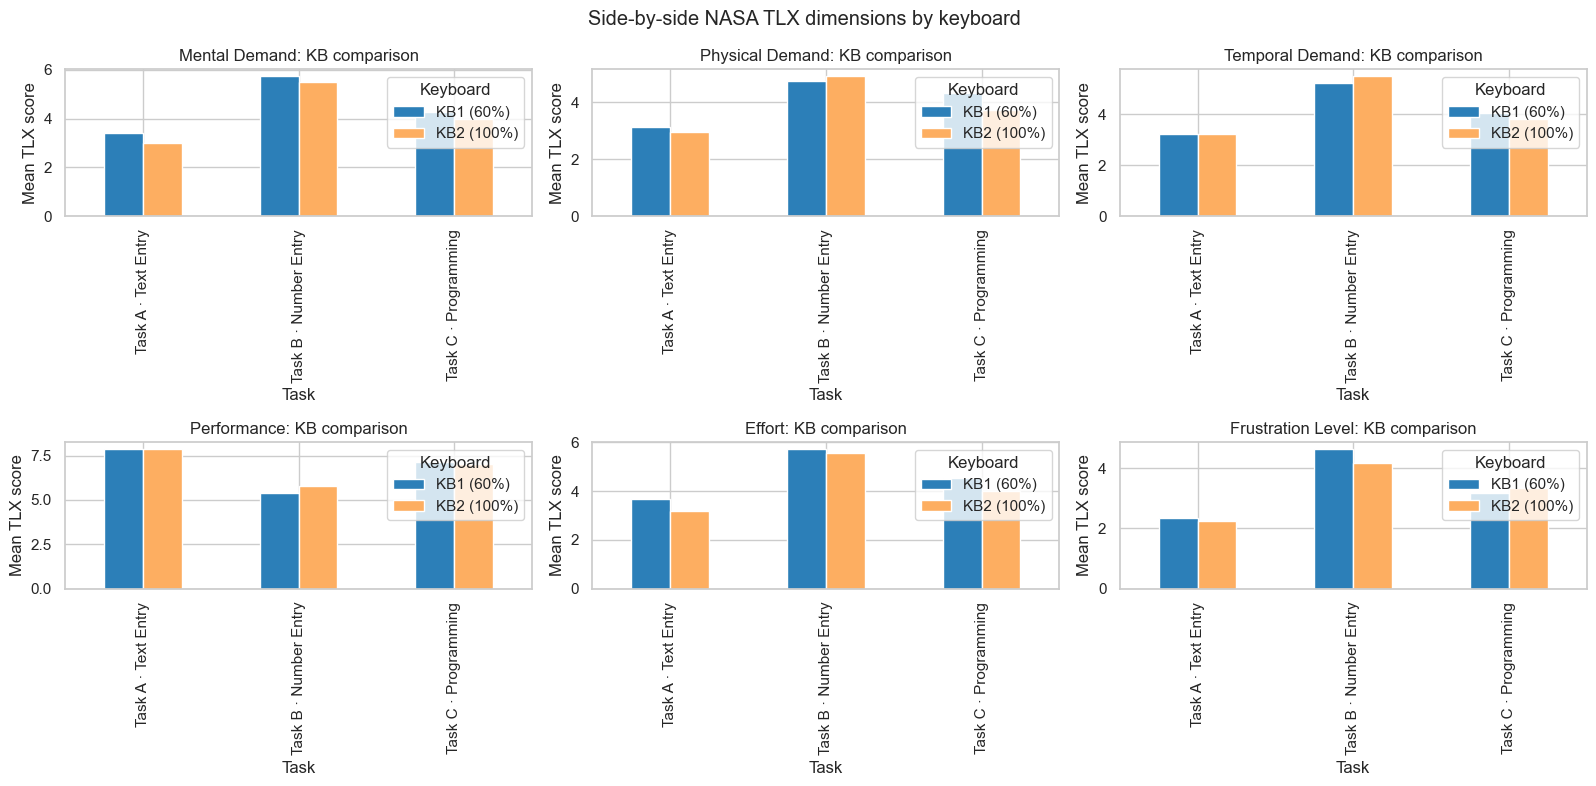

In [282]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ["#2c7fb8", "#fdae61"]
for ax, (dim, pivot) in zip(axes.ravel(), dimension_pivots.items()):
    pivot.plot(kind="bar", stacked=False, ax=ax, color=colors)
    ax.set_title(f"{dim}: KB comparison")
    ax.set_ylabel("Mean TLX score")
    ax.set_xlabel("Task")
    ax.legend(title="Keyboard", loc="upper right")
plt.suptitle("Side-by-side NASA TLX dimensions by keyboard")
plt.tight_layout()
plt.show()


## Statistical Analysis

### Preparing data for two-way repeated measures ANOVA

In [283]:
task_meta = {
    "Text": {"code": "A", "label": "Task A · Text Entry"},
    "Num": {"code": "B", "label": "Task B · Number Entry"},
    "Prog": {"code": "C", "label": "Task C · Programming"},
}
keyboard_meta_perf = {"60": "KB1 (60%)", "100": "KB2 (100%)"}
perf_metrics = [
    "WPM",
    "Accuracy",
    "ErrorRate",
    "MouseTime",
    "Clicks",
    "Backspaces",
    "Scrolls",
    "TotalTime",
    "CorrectChars",
    "IncorrectFixed",
    "IncorrectNotFixed",
]

perf_long = []
for task_prefix, task_info in task_meta.items():
    for kb_suffix, kb_label in keyboard_meta_perf.items():
        col_map = {metric: f"{task_prefix}_{kb_suffix}_{metric}" for metric in perf_metrics}
        available_cols = [col for col in col_map.values() if col in typing_test_df.columns]
        if len(available_cols) != len(perf_metrics):
            missing = sorted(set(col_map.values()) - set(available_cols))
            raise ValueError(f"Missing columns for {task_prefix} {kb_suffix}: {missing}")

        subset = typing_test_df[["Participant Number", "GroupNumber"] + available_cols].copy()
        subset = subset.rename(columns={v: k for k, v in col_map.items()})
        subset["Keyboard"] = kb_label
        subset["Task"] = task_info["label"]
        subset["TaskCode"] = task_info["code"]
        perf_long.append(subset)

perf_long = pd.concat(perf_long, ignore_index=True)
perf_long.head()

,Participant Number,GroupNumber,WPM,Accuracy,ErrorRate,MouseTime,Clicks,Backspaces,Scrolls,TotalTime,CorrectChars,IncorrectFixed,IncorrectNotFixed,Keyboard,Task,TaskCode
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,304,25,0,KB1 (60%),Task A · Text Entry,A
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,304,54,0,KB1 (60%),Task A · Text Entry,A
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,345,40,0,KB1 (60%),Task A · Text Entry,A
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,345,24,0,KB1 (60%),Task A · Text Entry,A
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,345,23,0,KB1 (60%),Task A · Text Entry,A


In [284]:
# Prepare NASA TLX with keyboard labels and task codes
keyboard_meta_tlx = {1: "KB1 (60%)", 2: "KB2 (100%)"}

# Task codes are already A/B/C in nasa_tlx_df["Task Type"]. We keep both code and label.
if "Task Type" not in nasa_tlx_df.columns:
    raise KeyError("Expected 'Task Type' column in nasa_tlx_df")

nasa_pref = nasa_tlx_df.copy()
nasa_pref["Keyboard"] = nasa_pref["Keyboard Type"].map(keyboard_meta_tlx)
nasa_pref["TaskCode"] = nasa_pref["Task Type"]  # A, B, C

# Keep one row per participant × keyboard × task, including Original Keyboard and TLX dimensions
nasa_pref = nasa_pref[
    [
        "Participant Number",
        "Original Keyboard",
        "Keyboard",
        "TaskCode",
        "Mental Demand",
        "Physical Demand",
        "Temporal Demand",
        "Performance",
        "Effort",
        "Frustration Level",
    ]
]

# Merge with long-format performance data (perf_long)
if "Participant Number" not in perf_long.columns:
    raise KeyError("Expected 'Participant Number' in perf_long. Make sure the reshaping cell ran.")

perf_tlx = perf_long.merge(
    nasa_pref,
    on=["Participant Number", "Keyboard", "TaskCode"],
    how="inner",
)

# Helper to compute PreferenceMatch based on Original Keyboard and test Keyboard

def compute_preference_match(original_kb: str, test_keyboard: str) -> int:
    """Return 1 if the test keyboard matches the participant's original/preferred keyboard.

    Rules implemented:
    - "Original Keyboard" = "100" AND Keyboard = "KB2 (100%)"
    - "Original Keyboard" = "60" AND Keyboard = "KB1 (60%)"
    - "Original Keyboard" = "Both"  → matches both keyboards
    - "Original Keyboard" contains "100" (e.g., "75 and 100") AND Keyboard = "KB2 (100%)"
    - "Original Keyboard" contains "60" AND Keyboard = "KB1 (60%)"
    - Otherwise → 0
    """
    if pd.isna(original_kb) or pd.isna(test_keyboard):
        return 0

    okb = str(original_kb).strip().lower()
    tkb = str(test_keyboard).strip().lower()

    # Normalize test keyboard to a simple code
    if "60%" in tkb or "kb1" in tkb:
        test_code = "60"
    elif "100%" in tkb or "kb2" in tkb:
        test_code = "100"
    else:
        return 0  # non-60/100 layouts never count as a match

    # Exact matches
    if okb == "both":
        return 1
    if okb == "60" and test_code == "60":
        return 1
    if okb == "100" and test_code == "100":
        return 1

    # Partial-string matches
    if "60" in okb and test_code == "60":
        return 1
    if "100" in okb and test_code == "100":
        return 1

    # All other cases, including TKL, Laptop, 75, etc.
    return 0


perf_tlx["PreferenceMatch"] = perf_tlx.apply(
    lambda row: compute_preference_match(row["Original Keyboard"], row["Keyboard"]), axis=1
)

# Verification table
verification_cols = [
    "Participant Number",
    "Original Keyboard",
    "Keyboard",
    "TaskCode",
    "PreferenceMatch",
]
preference_verification = (
    perf_tlx[verification_cols]
    .drop_duplicates()
    .sort_values(["Participant Number", "Keyboard", "TaskCode"])
    .reset_index(drop=True)
)

# Save updated dataset and verification table
os.makedirs("results", exist_ok=True)
perf_tlx.to_csv("results/perf_tlx_with_preference.csv", index=False)
preference_verification.to_csv("results/preference_verification.csv", index=False)

preference_verification.head()

,Participant Number,Original Keyboard,Keyboard,TaskCode,PreferenceMatch
0,1,TKL,KB1 (60%),A,0
1,1,TKL,KB1 (60%),B,0
2,1,TKL,KB1 (60%),C,0
3,1,TKL,KB2 (100%),A,0
4,1,TKL,KB2 (100%),B,0


### Two-way repeated measures ANOVA: Setup

In [285]:
# Repeated-measures ANOVA readiness verification
from itertools import product
from pandas.api.types import CategoricalDtype

try:
    df = perf_long.copy()
except NameError as err:
    raise NameError(
        "perf_long is not defined earlier in the notebook; please load/reshape the data before running checks"
    ) from err

participant_col = "Participant_Number"
if participant_col not in df.columns:
    df = df.rename(columns={"Participant Number": participant_col})

factor_cols = [participant_col, "Keyboard", "Task"]
for col in factor_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Factor dtype overview:")
factor_dtype_report = pd.Series({col: str(df[col].dtype) for col in factor_cols})
print(factor_dtype_report)

non_categorical = [
    col for col in factor_cols
    if not isinstance(df[col].dtype, CategoricalDtype)
]
if non_categorical:
    print(f"Non-categorical factors detected: {non_categorical}")
else:
    print("All factor columns are categorical.")

condition_counts = (
    df.groupby(factor_cols, dropna=False)
    .size()
    .reset_index(name="row_count")
)
duplicate_condition_rows = condition_counts[condition_counts["row_count"] > 1]
if duplicate_condition_rows.empty:
    print("No duplicated participant × keyboard × task rows detected.")
else:
    print("Duplicated participant × keyboard × task rows detected:")
    display(duplicate_condition_rows.sort_values(factor_cols).reset_index(drop=True))

participants = df[participant_col].unique()
keyboards = df["Keyboard"].unique()
tasks = df["Task"].unique()
expected_conditions = len(keyboards) * len(tasks)
print(f"Unique participants: {len(participants)} | keyboards: {len(keyboards)} | tasks: {len(tasks)}")
print(f"Expected conditions per participant: {expected_conditions}")

missing_records = []
for participant in participants:
    participant_slice = condition_counts[condition_counts[participant_col] == participant]
    for kb, task in product(keyboards, tasks):
        mask = (participant_slice["Keyboard"] == kb) & (participant_slice["Task"] == task)
        if not mask.any():
            missing_records.append({
                participant_col: participant,
                "Keyboard": kb,
                "Task": task,
            })

if missing_records:
    missing_cells = pd.DataFrame(missing_records)
    print(
        f"Missing cells detected: {len(missing_cells)} participant × keyboard × task combinations are absent."
    )
    display(
        missing_cells.sort_values([participant_col, "Keyboard", "Task"]).reset_index(drop=True)
    )
else:
    print("All participants have measurements for every keyboard × task combination.")

imbalanced_participants = (
    condition_counts.groupby(participant_col).size().reset_index(name="observed_conditions")
)
imbalanced_participants = imbalanced_participants[
    imbalanced_participants["observed_conditions"] != expected_conditions
]
if imbalanced_participants.empty:
    print("Balanced design confirmed: each participant has one row per condition.")
else:
    print("Imbalanced participants detected (unexpected number of conditions):")
    display(imbalanced_participants)

Factor dtype overview:
Participant_Number    category
Keyboard              category
Task                  category
dtype: object
All factor columns are categorical.
No duplicated participant × keyboard × task rows detected.
Unique participants: 33 | keyboards: 2 | tasks: 3
Expected conditions per participant: 6
All participants have measurements for every keyboard × task combination.
Balanced design confirmed: each participant has one row per condition.


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1580750328.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(factor_cols, dropna=False)
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1580750328.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_counts.groupby(participant_col).size().reset_index(name="observed_conditions")


In [286]:
def run_two_way_rm_anova(
    data,
    depvar,
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
    coerce_numeric=True,
):
    """
    Fit an AnovaRM model and print both the ANOVA table and a short interpretation.

    Returns
    -------
    dict | None
        Dictionary containing the fitted model, ANOVA table, and interpretation lines.
    """
    required_cols = [depvar, subject_col, *within_factors]
    missing = [col for col in required_cols if col not in data.columns]
    if missing:
        raise KeyError(f"Columns missing from dataframe: {missing}")

    anova_df = data.copy()
    if coerce_numeric:
        anova_df[depvar] = pd.to_numeric(anova_df[depvar], errors="coerce")

    for col in [subject_col, *within_factors]:
        if col in anova_df.columns and not isinstance(anova_df[col].dtype, CategoricalDtype):
            anova_df[col] = anova_df[col].astype("category")

    try:
        model = AnovaRM(
            data=anova_df,
            depvar=depvar,
            subject=subject_col,
            within=list(within_factors),
        ).fit()
    except ValueError as err:
        print(f"ANOVA failed for {depvar}: {err}")
        participant_counts = anova_df.groupby(subject_col)
        for factor in within_factors:
            level_span = participant_counts[factor].nunique()
            print(f"{factor} levels per participant: {level_span.min()}–{level_span.max()}")
        print("Suggested fix: ensure every participant has one row per keyboard × task combination and rerun.")
        return None

    table = model.anova_table.copy()
    print(f"=== {depvar} ANOVA table ===")
    print(model)

    interpret_lines = []
    for effect, row in table.iterrows():
        f_val = row.get("F Value")
        p_val = row.get("Pr > F")
        if pd.notna(f_val) and pd.notna(p_val):
            significance = "significant" if p_val < alpha else "not significant"
            interpret_lines.append(
                f"{effect}: F={f_val:.3f}, p={p_val:.4f} ({significance} at α={alpha})"
            )

    if interpret_lines:
        print("\nInterpretation:")
        print("\n".join(interpret_lines))

    return {"model": model, "anova_table": table, "interpretation": interpret_lines}

### Two-way repeated measures ANOVA: Typing Performance

In [287]:
# Two-way repeated-measures ANOVA: WPM ~ Keyboard * Task
wpm_result = run_two_way_rm_anova(
    data=df,
    depvar="WPM",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)


=== WPM ANOVA table ===
                   Anova
              F Value  Num DF  Den DF Pr > F
--------------------------------------------
Keyboard        0.0152 1.0000 32.0000 0.9027
Task          244.6441 2.0000 64.0000 0.0000
Keyboard:Task   0.3884 2.0000 64.0000 0.6797


Interpretation:
Keyboard: F=0.015, p=0.9027 (not significant at α=0.05)
Task: F=244.644, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.388, p=0.6797 (not significant at α=0.05)


Interpretation of results above:

#### 1. Main Effect of Keyboard — NOT significant

F(1, 32) = 0.0152, p = .9027 → No keyboard effect

This means:

Participants did not type faster on one keyboard versus the other.

WPM performance on the 60% keyboard and the 100% keyboard is statistically indistinguishable.

A p-value this large (0.90) means the effect is extremely unlikely to be meaningful.

#### 2. Main Effect of Task — VERY significant

F(2, 64) = 244.644, p < .0001 → Strong task effect

This means:

Task type massively affects typing speed.

Participants typed at very different speeds depending on whether the task was:

Text typing (Task A)

Number entry (Task B)

Programming-like entry (Task C)

Still need post-hoc tests (pairwise comparison of A vs B vs C) to determine exactly which tasks differ — but given F ≈ 245, the differences are almost certainly large and clear.

#### 3. Keyboard × Task Interaction — NOT significant

F(2, 64) = 0.3884, p = .6797 → No interaction

This means:

The effect of Task does not depend on the keyboard type.

The difference between Tasks A, B, and C is consistent regardless of whether participants used the 60% or 100% keyboard.

Basically... switching keyboards doesn’t change which tasks are easier or harder.


In [288]:
# Two-way repeated-measures ANOVA: Accuracy ~ Keyboard * Task
accuracy_result = run_two_way_rm_anova(
    data=df,
    depvar="Accuracy",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)


=== Accuracy ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       0.8130 1.0000 32.0000 0.3740
Task          11.6547 2.0000 64.0000 0.0000
Keyboard:Task  0.0161 2.0000 64.0000 0.9840


Interpretation:
Keyboard: F=0.813, p=0.3740 (not significant at α=0.05)
Task: F=11.655, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.016, p=0.9840 (not significant at α=0.05)


#### Two-way repeated-measures ANOVA: Error Rate

In [289]:
error_rate_result = run_two_way_rm_anova(
    data=df,
    depvar="ErrorRate",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== ErrorRate ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       2.7054 1.0000 32.0000 0.1098
Task          35.4611 2.0000 64.0000 0.0000
Keyboard:Task  0.1737 2.0000 64.0000 0.8410


Interpretation:
Keyboard: F=2.705, p=0.1098 (not significant at α=0.05)
Task: F=35.461, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.174, p=0.8410 (not significant at α=0.05)


### Two-way repeated-measures ANOVA: NASA TLX dimensions


In [290]:
nasa_rm_df = nasa_aug.rename(columns={"Participant Number": "Participant_Number"}).copy()
nasa_rm_results = {}

#### Mental Demand

In [291]:
nasa_rm_results["Mental Demand"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Mental Demand",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== Mental Demand ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       2.8772 1.0000 32.0000 0.0995
Task          58.6257 2.0000 64.0000 0.0000
Keyboard:Task  0.1568 2.0000 64.0000 0.8552


Interpretation:
Keyboard: F=2.877, p=0.0995 (not significant at α=0.05)
Task: F=58.626, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.157, p=0.8552 (not significant at α=0.05)


#### Physical Demand


In [292]:
nasa_rm_results["Physical Demand"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Physical Demand",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== Physical Demand ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       0.8434 1.0000 32.0000 0.3653
Task          23.9400 2.0000 64.0000 0.0000
Keyboard:Task  1.6592 2.0000 64.0000 0.1984


Interpretation:
Keyboard: F=0.843, p=0.3653 (not significant at α=0.05)
Task: F=23.940, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=1.659, p=0.1984 (not significant at α=0.05)


#### Temporal Demand


In [293]:
nasa_rm_results["Temporal Demand"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Temporal Demand",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== Temporal Demand ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       0.0023 1.0000 32.0000 0.9622
Task          32.2860 2.0000 64.0000 0.0000
Keyboard:Task  0.6256 2.0000 64.0000 0.5382


Interpretation:
Keyboard: F=0.002, p=0.9622 (not significant at α=0.05)
Task: F=32.286, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.626, p=0.5382 (not significant at α=0.05)


#### Performance


In [294]:
nasa_rm_results["Performance"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Performance",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== Performance ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       0.1382 1.0000 32.0000 0.7126
Task          30.9447 2.0000 64.0000 0.0000
Keyboard:Task  0.4794 2.0000 64.0000 0.6213


Interpretation:
Keyboard: F=0.138, p=0.7126 (not significant at α=0.05)
Task: F=30.945, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.479, p=0.6213 (not significant at α=0.05)


#### Effort


In [295]:
nasa_rm_results["Effort"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Effort",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== Effort ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       2.6608 1.0000 32.0000 0.1127
Task          40.4714 2.0000 64.0000 0.0000
Keyboard:Task  0.5608 2.0000 64.0000 0.5735


Interpretation:
Keyboard: F=2.661, p=0.1127 (not significant at α=0.05)
Task: F=40.471, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.561, p=0.5735 (not significant at α=0.05)


#### Frustration Level


In [296]:
nasa_rm_results["Frustration Level"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Frustration Level",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

=== Frustration Level ANOVA table ===
                   Anova
              F Value Num DF  Den DF Pr > F
-------------------------------------------
Keyboard       0.2979 1.0000 32.0000 0.5890
Task          26.9660 2.0000 64.0000 0.0000
Keyboard:Task  0.7934 2.0000 64.0000 0.4567


Interpretation:
Keyboard: F=0.298, p=0.5890 (not significant at α=0.05)
Task: F=26.966, p=0.0000 (significant at α=0.05)
Keyboard:Task: F=0.793, p=0.4567 (not significant at α=0.05)


### Preference Match Analysis

Prepare dependent variables for mixed-effects models

In [297]:
# Dependent variables grouped by interpretation
perf_higher_better = ["WPM", "Accuracy"]
# Treat Backspaces and TotalTime as intermediates only, not dependent variables
perf_lower_better = ["ErrorRate"]

nasa_lower_better = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Effort",
    "Frustration Level",
]
# In this study, higher NASA-TLX Performance = better perceived performance
nasa_higher_better = ["Performance"]

all_dvs = (
    perf_higher_better
    + perf_lower_better
    + nasa_lower_better
    + nasa_higher_better
)

# Ensure numeric types
for col in all_dvs:
    if col in perf_tlx.columns:
        perf_tlx[col] = pd.to_numeric(perf_tlx[col], errors="coerce")

# Ensure predictors are categorical / properly coded
perf_tlx["PreferenceMatch"] = perf_tlx["PreferenceMatch"].astype(int)
perf_tlx["TaskCode"] = perf_tlx["TaskCode"].astype("category")
perf_tlx["Participant_Number"] = perf_tlx["Participant Number"].astype("category")

# Quick sanity check
perf_tlx[[
    "Participant Number",
    "Keyboard",
    "TaskCode",
    "PreferenceMatch",
    "WPM",
    "Accuracy",
    "ErrorRate",
]].head()


,Participant Number,Keyboard,TaskCode,PreferenceMatch,WPM,Accuracy,ErrorRate
0,2,KB1 (60%),A,0,89.0,92.4,7.6
1,3,KB1 (60%),A,0,73.7,84.9,15.1
2,4,KB1 (60%),A,0,61.7,89.6,10.4
3,5,KB1 (60%),A,0,68.8,93.5,6.5
4,12,KB1 (60%),A,0,53.1,93.8,6.2


Mixed-effects models: PreferenceMatch × TaskCode

In [298]:
# Mixed-effects models (fixed DV quoting): PreferenceMatch × TaskCode
# Re-run this cell instead of the earlier mixed-model loop if you hit Patsy
# syntax errors for DVs with spaces (e.g., "Mental Demand").

from collections import defaultdict

mixed_results = {}
mm_marginal_means = {}

for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    model_data = perf_tlx[[
        "Participant_Number",
        "PreferenceMatch",
        "TaskCode",
        dv,
    ]].dropna().copy()

    # Use a safely quoted DV name for Patsy when the column has spaces or
    # characters that are not valid Python identifiers (e.g., "Mental Demand").
    if dv.isidentifier():
        dv_term = dv
    else:
        dv_term = f'Q("{dv}")'

    # Mixed-effects model with random intercept for participant
    # DV ~ PreferenceMatch * TaskCode + (1 | Participant_Number)
    formula_mixed = f"{dv_term} ~ PreferenceMatch * C(TaskCode)"
    md = smf.mixedlm(formula_mixed, data=model_data, groups=model_data["Participant_Number"])
    mdf = md.fit(reml=False, method="lbfgs")

    print("\n" + "=" * 80)
    print(f"Mixed-effects model for {dv}")
    print(mdf.summary())

    # Approximate F-tests and partial eta-squared using type III ANOVA from an OLS model
    # with Participant as a fixed blocking factor. This is equivalent to a random intercept
    # in a balanced design and provides standard F-statistics.
    formula_ols = f"{dv_term} ~ C(PreferenceMatch) * C(TaskCode) + C(Participant_Number)"
    ols_model = smf.ols(formula_ols, data=model_data).fit()
    anova_tbl = anova_lm(ols_model, typ=3)

    # Extract rows of interest
    effect_labels = {
        "C(PreferenceMatch)": "PreferenceMatch",
        "C(TaskCode)": "TaskCode",
        "C(PreferenceMatch):C(TaskCode)": "PreferenceMatch:TaskCode",
    }

    ss_error = anova_tbl.loc["Residual", "sum_sq"]
    dv_results = {}

    for row_label, pretty_label in effect_labels.items():
        if row_label not in anova_tbl.index:
            continue
        row = anova_tbl.loc[row_label]
        f_val = row["F"]
        p_val = row["PR(>F)"]
        df_num = row["df"]
        df_den = anova_tbl.loc["Residual", "df"]
        eta_p = np.nan
        if not np.isnan(f_val):
            ss_effect = row["sum_sq"]
            eta_p = ss_effect / (ss_effect + ss_error) if (ss_effect + ss_error) > 0 else np.nan

        dv_results[pretty_label] = {
            "F": float(f_val) if not np.isnan(f_val) else np.nan,
            "p": float(p_val) if not np.isnan(p_val) else np.nan,
            "df_num": float(df_num),
            "df_den": float(df_den),
            "eta_p2": float(eta_p) if not np.isnan(eta_p) else np.nan,
        }

    # Marginal means for PreferenceMatch (collapsing over TaskCode)
    mm = (
        model_data
        .groupby("PreferenceMatch")[dv]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Mean", "std": "SD", "count": "N"})
    )
    # 95% CI using normal approximation
    mm["SE"] = mm["SD"] / np.sqrt(mm["N"])
    mm["CI_lower"] = mm["Mean"] - 1.96 * mm["SE"]
    mm["CI_upper"] = mm["Mean"] + 1.96 * mm["SE"]

    mixed_results[dv] = dv_results
    mm_marginal_means[dv] = mm

# Convert mixed model results to a tidy table and save
rows = []
for dv, effects in mixed_results.items():
    for effect_name, stats_dict in effects.items():
        rows.append({
            "DV": dv,
            "Effect": effect_name,
            **stats_dict,
        })

mixed_results_df = pd.DataFrame(rows)

os.makedirs("results", exist_ok=True)
mixed_results_df.to_csv("results/mixed_model_results.csv", index=False)

# Also save marginal means
mm_rows = []
for dv, table in mm_marginal_means.items():
    for pref, row in table.iterrows():
        mm_rows.append({
            "DV": dv,
            "PreferenceMatch": int(pref),
            "Mean": row["Mean"],
            "SD": row["SD"],
            "N": int(row["N"]),
            "SE": row["SE"],
            "CI_lower": row["CI_lower"],
            "CI_upper": row["CI_upper"],
        })

mm_df = pd.DataFrame(mm_rows)
mm_df.to_csv("results/marginal_means_preference.csv", index=False)

mixed_results_df.head()



Mixed-effects model for WPM
                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         WPM      
No. Observations:         198             Method:                     ML       
No. Groups:               33              Scale:                      74.2029  
Min. group size:          6               Log-Likelihood:             -745.2822
Max. group size:          6               Converged:                  Yes      
Mean group size:          6.0                                                  
-------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                         68.250    2.256  30.248 0.000  63.827  72.672
C(TaskCode)[T.B]                 -39.289    1.816 -21.635 0.000 -42.848 -35.730
C(TaskCode)[T.C]                

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Mixed-effects model for Physical Demand
                   Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Q("Physical Demand")
No. Observations:    198        Method:                ML                  
No. Groups:          33         Scale:                 1.7189              
Min. group size:     6          Log-Likelihood:        -370.0105           
Max. group size:     6          Converged:             Yes                 
Mean group size:     6.0                                                   
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         3.507    0.325 10.794 0.000  2.870  4.144
C(TaskCode)[T.B]                  1.467    0.276  5.306 0.000  0.925  2.008
C(TaskCode)[T.C]                  0.844    0.276  3.055 0.002  0.3

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,DV,Effect,F,p,df_num,df_den,eta_p2
0,WPM,PreferenceMatch,3.149075,7.787166e-02,1.0,160.0,0.019302
1,WPM,TaskCode,249.713127,6.256045e-50,2.0,160.0,0.757365
2,WPM,PreferenceMatch:TaskCode,1.146284,3.204116e-01,2.0,160.0,0.014126
3,Accuracy,PreferenceMatch,0.003858,9.505513e-01,1.0,160.0,0.000024
4,Accuracy,TaskCode,9.405449,1.374295e-04,2.0,160.0,0.105200


In [299]:
### Visualizations: PreferenceMatch effects

sns.set_theme(style="whitegrid", context="notebook")

# 4.1 Summary bar charts: DV mean by PreferenceMatch, faceted by TaskCode
for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        kind="bar",
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        ci=95,
        errorbar=("ci", 95),
        palette="Set2",
        height=4,
        aspect=0.9,
    )

    # Add sample sizes in titles
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):
        counts = sub_df.groupby("PreferenceMatch")[dv].count()
        label_parts = [f"Pref={k}: n={v}" for k, v in counts.items()]
        ax.set_title(f"Task {task_code} | " + ", ".join(label_parts))
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    g.figure.suptitle(f"Mean {dv} by PreferenceMatch and TaskCode", y=1.05)
    plt.tight_layout()
    out_path = f"results/bar_{dv.replace(' ', '_')}_by_preference_task.png"
    g.savefig(out_path, dpi=300)
    plt.close(g.figure)


# 4.2 Interaction plots: TaskCode × PreferenceMatch
for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    plt.figure(figsize=(6, 4))
    ax = sns.pointplot(
        data=perf_tlx,
        x="TaskCode",
        y=dv,
        hue="PreferenceMatch",
        dodge=True,
        markers=["o", "s"],
        linestyles=["--", "-"],
        errorbar=("ci", 95),
        palette="Set1",
    )
    ax.set_title(f"Interaction: TaskCode × PreferenceMatch on {dv}")
    ax.set_ylabel(dv)
    ax.set_xlabel("TaskCode")
    ax.legend(title="PreferenceMatch (0 = No, 1 = Yes)")
    plt.tight_layout()

    out_path = f"results/interaction_{dv.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=300)
    plt.close()


# 4.3 Distribution plots (box/violin + points) for key metrics
key_dists = ["WPM", "Accuracy", "Mental Demand", "Physical Demand", "Performance"]

for dv in key_dists:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        kind="violin",
        inner=None,
        palette="Pastel1",
        height=4,
        aspect=0.9,
    )

    # Overlay individual points
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):
        sns.stripplot(
            data=sub_df,
            x="PreferenceMatch",
            y=dv,
            dodge=True,
            alpha=0.6,
            color="k",
            size=3,
            ax=ax,
        )
        ax.set_title(f"Task {task_code}")
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    g.figure.suptitle(f"Distribution of {dv} by PreferenceMatch and TaskCode", y=1.05)
    plt.tight_layout()

    out_path = f"results/dist_{dv.replace(' ', '_')}_by_preference_task.png"
    g.savefig(out_path, dpi=300)
    plt.close(g.figure)


# 4.4 Sample size summary plots
sample_counts = (
    perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=sample_counts,
    x="TaskCode",
    y="N",
    hue="PreferenceMatch",
    palette="Set2",
)
ax.set_title("Sample sizes by PreferenceMatch and TaskCode")
ax.set_ylabel("Number of observations")
ax.set_xlabel("TaskCode")
ax.legend(title="PreferenceMatch (0 = No, 1 = Yes)")
plt.tight_layout()
plt.savefig("results/sample_sizes_preference_task.png", dpi=300)
plt.close()

sample_counts


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1028658488.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1028658488.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1028658488.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1028658488.py:10: FutureWarning: 

Passing `

,PreferenceMatch,TaskCode,N
0,0,A,45
1,0,B,45
2,0,C,45
3,1,A,21
4,1,B,21
5,1,C,21


In [300]:
### Summary report generation

# 1. Sample overview
n_participants = perf_tlx["Participant Number"].nunique()

# Participants whose original keyboard allows a PreferenceMatch = 1 on at least one condition
participant_pref = (
    perf_tlx.groupby("Participant Number")["PreferenceMatch"].max().reset_index()
)
participants_with_match_possible = (participant_pref["PreferenceMatch"] == 1).sum()
participants_without_match = n_participants - participants_with_match_possible

obs_counts = perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")
obs_total = len(perf_tlx)

# 2. Statistical results table (pivoted from mixed_results_df)
results_wide = (
    mixed_results_df
    .pivot_table(
        index="DV",
        columns="Effect",
        values=["F", "p", "eta_p2"],
    )
)
# Flatten MultiIndex columns
results_wide.columns = [f"{m}_{e}" for m, e in results_wide.columns]
results_wide = results_wide.reset_index()

results_wide.to_csv("results/statistical_results_table.csv", index=False)

# 3. Key findings: identify significant effects (p < 0.05)
alpha = 0.05

sig_pref = mixed_results_df[
    (mixed_results_df["Effect"] == "PreferenceMatch") & (mixed_results_df["p"] < alpha)
]
sig_task = mixed_results_df[
    (mixed_results_df["Effect"] == "TaskCode") & (mixed_results_df["p"] < alpha)
]
sig_inter = mixed_results_df[
    (mixed_results_df["Effect"] == "PreferenceMatch:TaskCode") & (mixed_results_df["p"] < alpha)
]

# Helper to format mean differences with CIs for a given DV
from textwrap import indent

mm_df_pivot = mm_df.pivot_table(
    index="DV",
    columns="PreferenceMatch",
    values=["Mean", "CI_lower", "CI_upper"],
)


def format_mm_line(dv: str) -> str:
    if dv not in mm_df_pivot.index:
        return ""
    row = mm_df_pivot.loc[dv]
    try:
        mean0 = row["Mean"][0]
        l0 = row["CI_lower"][0]
        u0 = row["CI_upper"][0]
        mean1 = row["Mean"][1]
        l1 = row["CI_lower"][1]
        u1 = row["CI_upper"][1]
    except KeyError:
        return ""
    return (
        f"{dv}: Pref=0 mean={mean0:.2f} [{l0:.2f}, {u0:.2f}], "
        f"Pref=1 mean={mean1:.2f} [{l1:.2f}, {u1:.2f}]"
    )


# 4. Assemble human-readable report
lines = []
lines.append("Keyboard Preference Matching: Mixed-Effects Analysis Report")
lines.append("".join(["="] * len(lines[-1])))
lines.append("")

# Sample overview
lines.append("1. Sample Overview")
lines.append(f"- Total participants: {n_participants}")
lines.append(
    f"- Participants with at least one PreferenceMatch=1 condition: {participants_with_match_possible}"
)
lines.append(
    f"- Participants with PreferenceMatch=0 only: {participants_without_match}"
)
lines.append(f"- Total observations (rows in perf_tlx): {obs_total}")
lines.append("- Observations by PreferenceMatch × TaskCode:")
for _, row in obs_counts.iterrows():
    lines.append(
        f"  - PreferenceMatch={int(row['PreferenceMatch'])}, TaskCode={row['TaskCode']}: N={int(row['N'])}"
    )
lines.append("")

# Statistical results summary
lines.append("2. Statistical Results (mixed models with participant random intercept)")
lines.append("- See 'results/mixed_model_results.csv' and 'results/statistical_results_table.csv' for full details.")
lines.append("")

# Key findings
lines.append("3. Key Findings (p < 0.05)")

if not sig_pref.empty:
    lines.append("- Dependent variables with a significant main effect of PreferenceMatch:")
    for dv in sig_pref["DV"].unique():
        sub = sig_pref[sig_pref["DV"] == dv].iloc[0]
        line = (
            f"  - {dv}: F({sub['df_num']:.0f}, {sub['df_den']:.0f}) = {sub['F']:.2f}, "
            f"p = {sub['p']:.3f}, partial eta² = {sub['eta_p2']:.3f}"
        )
        mm_line = format_mm_line(dv)
        if mm_line:
            line += f"; {mm_line}"
        lines.append(line)
else:
    lines.append("- No dependent variables showed a significant main effect of PreferenceMatch.")

if not sig_task.empty:
    lines.append("- Dependent variables with a significant main effect of TaskCode:")
    for dv in sig_task["DV"].unique():
        sub = sig_task[sig_task["DV"] == dv].iloc[0]
        lines.append(
            f"  - {dv}: F({sub['df_num']:.0f}, {sub['df_den']:.0f}) = {sub['F']:.2f}, "
            f"p < 0.05, partial eta² = {sub['eta_p2']:.3f}"
        )
else:
    lines.append("- No dependent variables showed a significant main effect of TaskCode.")

if not sig_inter.empty:
    lines.append("- Dependent variables with a significant PreferenceMatch × TaskCode interaction:")
    for dv in sig_inter["DV"].unique():
        sub = sig_inter[sig_inter["DV"] == dv].iloc[0]
        lines.append(
            f"  - {dv}: F({sub['df_num']:.0f}, {sub['df_den']:.0f}) = {sub['F']:.2f}, "
            f"p = {sub['p']:.3f}, partial eta² = {sub['eta_p2']:.3f}"
        )
else:
    lines.append("- No dependent variables showed a significant PreferenceMatch × TaskCode interaction.")

lines.append("")

# 4. Interpretation placeholder (you can refine wording after inspecting actual results)
lines.append("4. Interpretation (high-level)")
lines.append(
    "- Performance metrics where higher is better (WPM, Accuracy, TLX Performance) and lower is better (ErrorRate, Backspaces, TotalTime) "
    "can be interpreted directly using the marginal means reported above."
)
lines.append(
    "- NASA-TLX workload dimensions (Mental, Physical, Temporal Demand, Effort, Frustration) should decrease when the keyboard matches "
    "participant preference if preference matching reduces workload."
)
lines.append(
    "- Use the significant PreferenceMatch and interaction effects (if any) to support claims about whether matching the participant's "
    "preferred layout improves objective performance and/or reduces subjective workload, and whether these patterns differ by task type."
)

report_text = "\n".join(lines)

with open("results/summary_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)


Keyboard Preference Matching: Mixed-Effects Analysis Report

1. Sample Overview
- Total participants: 33
- Participants with at least one PreferenceMatch=1 condition: 20
- Participants with PreferenceMatch=0 only: 13
- Total observations (rows in perf_tlx): 198
- Observations by PreferenceMatch × TaskCode:
  - PreferenceMatch=0, TaskCode=A: N=45
  - PreferenceMatch=0, TaskCode=B: N=45
  - PreferenceMatch=0, TaskCode=C: N=45
  - PreferenceMatch=1, TaskCode=A: N=21
  - PreferenceMatch=1, TaskCode=B: N=21
  - PreferenceMatch=1, TaskCode=C: N=21

2. Statistical Results (mixed models with participant random intercept)
- See 'results/mixed_model_results.csv' and 'results/statistical_results_table.csv' for full details.

3. Key Findings (p < 0.05)
- Dependent variables with a significant main effect of PreferenceMatch:
  - Mental Demand: F(1, 160) = 6.85, p = 0.010, partial eta² = 0.041; Mental Demand: Pref=0 mean=4.53 [4.18, 4.89], Pref=1 mean=3.86 [3.36, 4.35]
  - Physical Demand: F(1, 160)

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/2954978310.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_counts = perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")


### PreferenceMatch × TaskCode: Key performance plots (inline)

The cells below re-create a subset of the preference visualizations **inline** (no files written),
with a small number of plots per cell so it is easier to see what is going on.

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1295760316.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1295760316.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


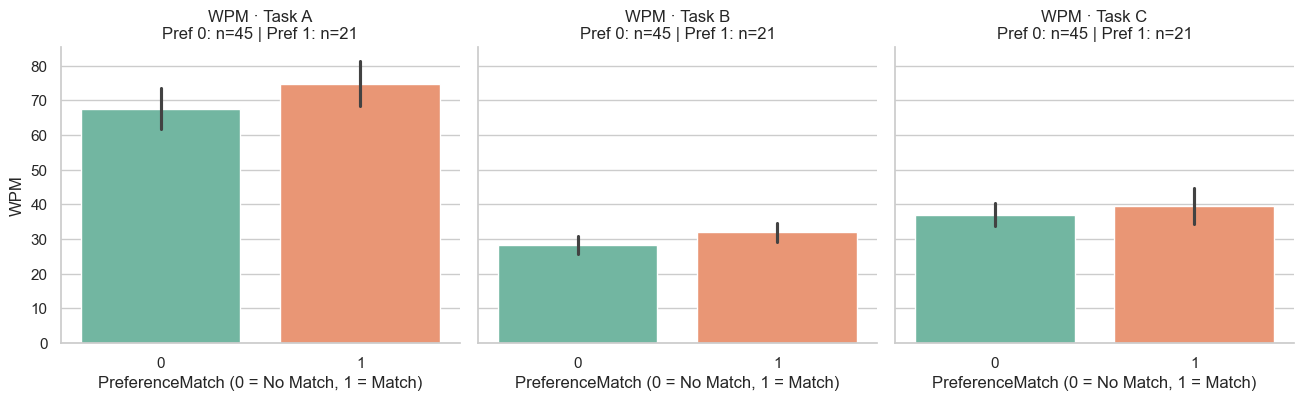

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1295760316.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1295760316.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


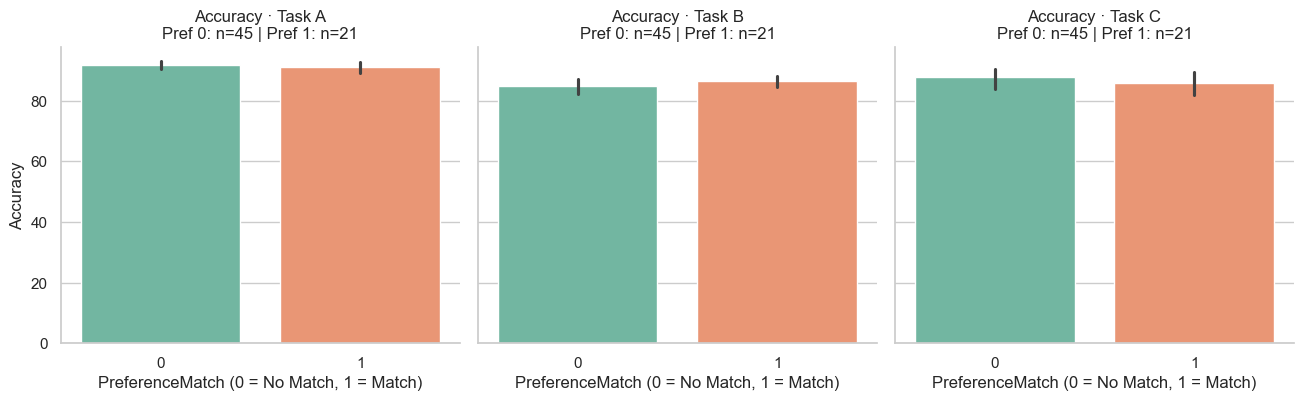

In [301]:
# Bar plots: WPM and Accuracy by PreferenceMatch × TaskCode (inline display only)

sns.set_theme(style="whitegrid", context="notebook")

for dv in ["WPM", "Accuracy"]:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        kind="bar",
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        errorbar=("ci", 95),
        palette="Set2",
        height=4,
        aspect=1.1,  # a bit wider facets for readability
    )

    # Add sample sizes in titles, formatted across two lines to avoid overlap
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):
        counts = sub_df.groupby("PreferenceMatch")[dv].count()
        # Ensure both levels 0 and 1 are shown even if one is missing
        n0 = int(counts.get(0, 0))
        n1 = int(counts.get(1, 0))
        title_line1 = f"{dv} · Task {task_code}"
        title_line2 = f"Pref 0: n={n0} | Pref 1: n={n1}"
        ax.set_title(f"{title_line1}\n{title_line2}")
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    # Rely on per-facet titles only; no global suptitle to keep text from colliding
    plt.show()


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


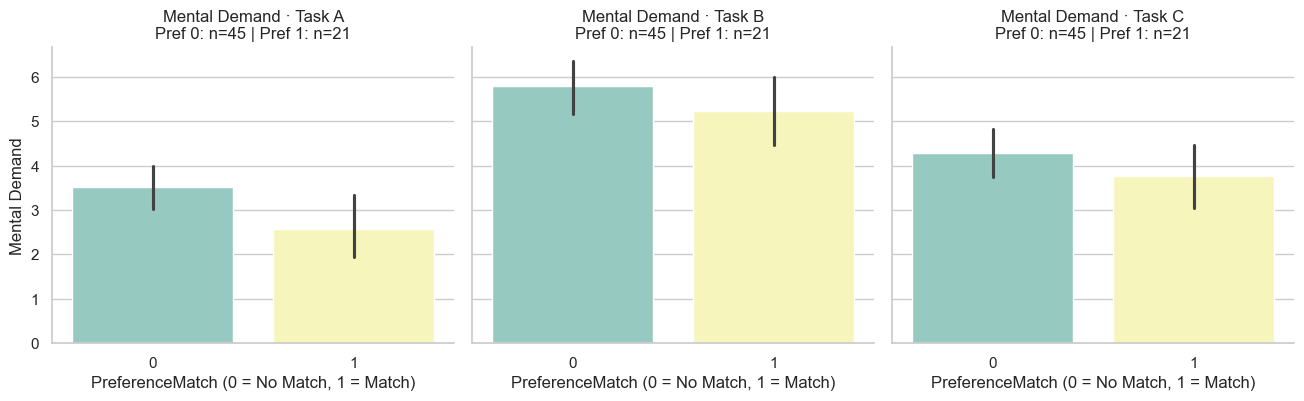

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


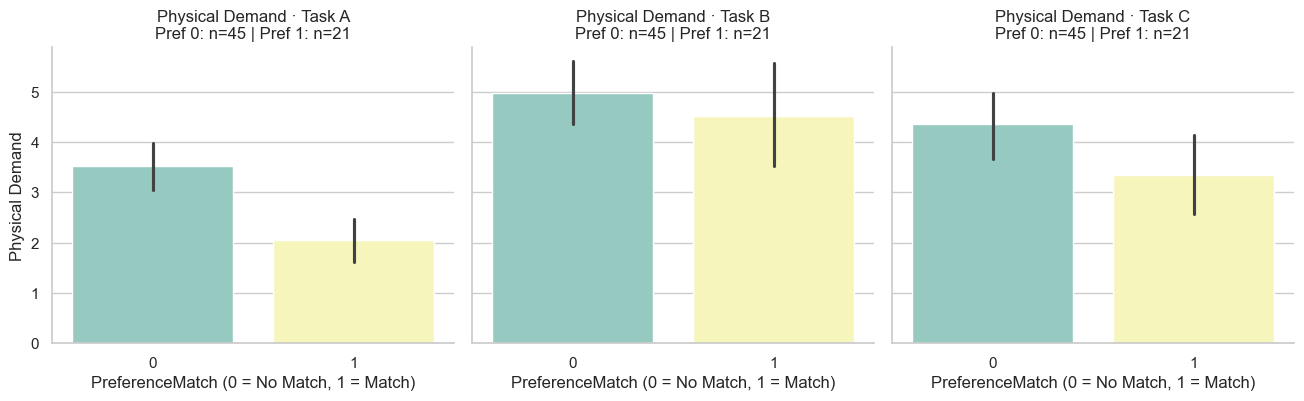

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


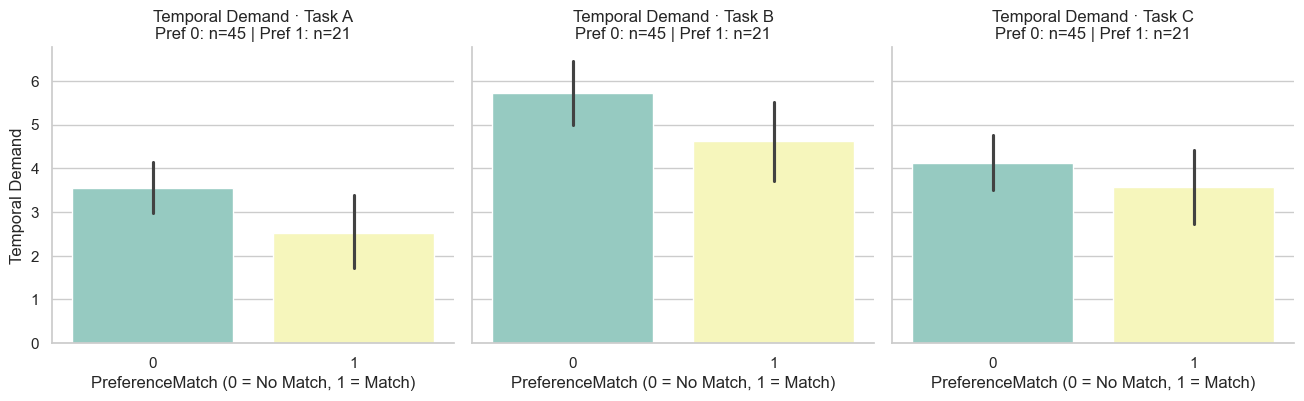

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


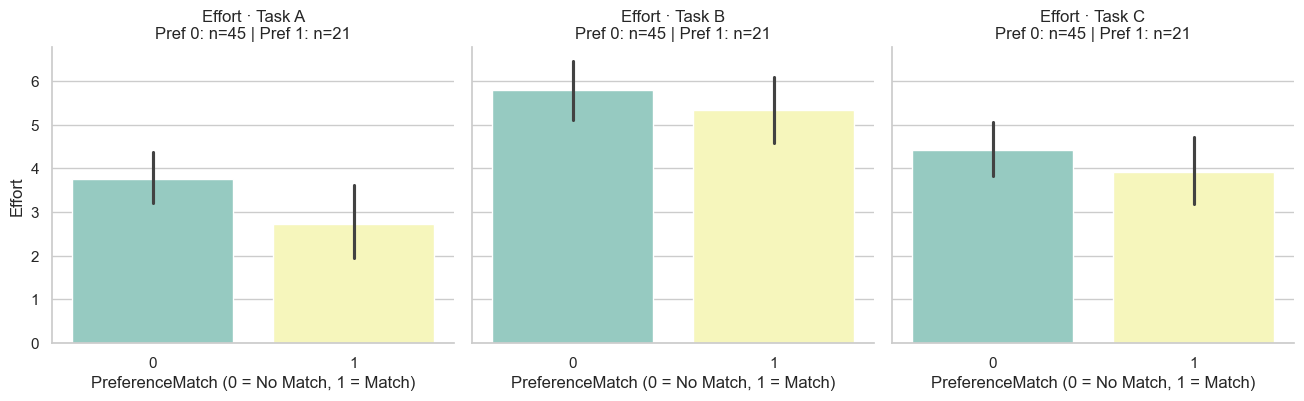

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/4003453002.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):


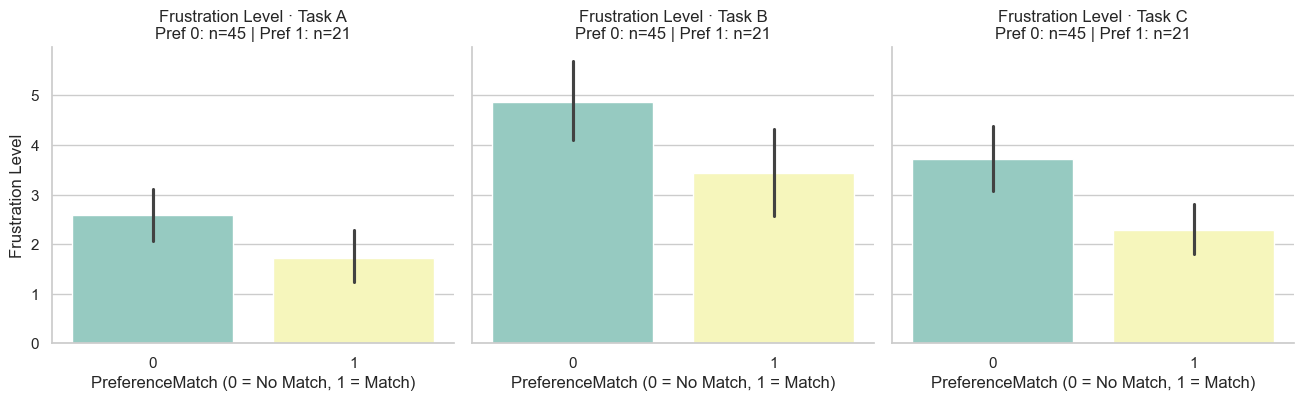

In [302]:
# Bar plots: NASA TLX workload dimensions by PreferenceMatch × TaskCode (inline)

workload_dvs = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Effort",
    "Frustration Level",
]

for dv in workload_dvs:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        kind="bar",
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        errorbar=("ci", 95),
        palette="Set3",
        height=4,
        aspect=1.1,  # slightly wider facets for clearer titles
    )

    # Add sample sizes in two-line titles for readability
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode")):
        counts = sub_df.groupby("PreferenceMatch")[dv].count()
        n0 = int(counts.get(0, 0))
        n1 = int(counts.get(1, 0))
        title_line1 = f"{dv} · Task {task_code}"
        title_line2 = f"Pref 0: n={n0} | Pref 1: n={n1}"
        ax.set_title(f"{title_line1}\n{title_line2}")
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    # Rely only on per-facet titles to avoid overlapping with a global suptitle
    plt.show()


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_43304/1109090115.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")


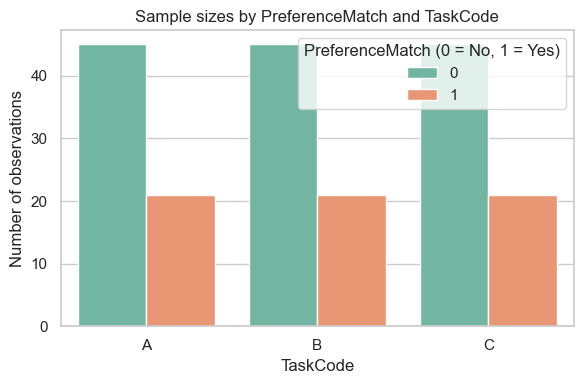

,PreferenceMatch,TaskCode,N
0,0,A,45
1,0,B,45
2,0,C,45
3,1,A,21
4,1,B,21
5,1,C,21


In [303]:
# Sample size bar plot: PreferenceMatch × TaskCode (inline)

sample_counts = (
    perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=sample_counts,
    x="TaskCode",
    y="N",
    hue="PreferenceMatch",
    palette="Set2",
)
ax.set_title("Sample sizes by PreferenceMatch and TaskCode")
ax.set_ylabel("Number of observations")
ax.set_xlabel("TaskCode")
ax.legend(title="PreferenceMatch (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

sample_counts


### Keyboard-Task Combo versus Typing Performance

In [304]:
numeric_cols = perf_metrics
perf_long[numeric_cols] = perf_long[numeric_cols].apply(pd.to_numeric, errors="coerce")

perf_summary = (
    perf_long.groupby(["Keyboard", "Task"])[["WPM", "Accuracy", "ErrorRate", "TotalTime"]]
    .agg(["mean", "std"])
    .round(2)
)
perf_summary


WPM        Accuracy        ErrorRate  \
                                   mean    std     mean    std      mean   
Keyboard   Task                                                            
KB1 (60%)  Task A · Text Entry    69.28  18.64    92.28   3.52      7.80   
           Task B · Number Entry  29.19   8.99    85.94  10.08     13.22   
           Task C · Programming   38.38  12.65    87.87  13.73     10.05   
KB2 (100%) Task A · Text Entry    70.31  19.48    90.99   4.69      8.39   
           Task B · Number Entry  29.54   7.74    85.10   4.68     14.12   
           Task C · Programming   37.38  11.93    86.80   7.95     11.34   

                                       TotalTime         
                                   std      mean    std  
Keyboard   Task                                          
KB1 (60%)  Task A · Text Entry    3.96     60.86  19.69  
           Task B · Number Entry  6.09    111.66  12.78  
           Task C · Programming   4.60     95.11  21.93  
KB2 (100%) Task A · Text Entry    4.53     60.22  20.86  
           Task B · Number Entry  4.76    112.30  12.55  
           Task C · Programming   4.31     97.96  20.36

Difference in Mean WPM for KB1 versus KB2. 

In [305]:
# TODO: Add more analysis here.
wpm_pivot = perf_long.groupby(["Task", "Keyboard"])['WPM'].mean().unstack()
wpm_pivot['Difference from KB2-KB1'] = wpm_pivot['KB2 (100%)'] - wpm_pivot['KB1 (60%)']
wpm_pivot.round(2)

Keyboard,KB1 (60%),KB2 (100%),Difference from KB2-KB1
Task,,,
Task A · Text Entry,69.28,70.31,1.03
Task B · Number Entry,29.19,29.54,0.35
Task C · Programming,38.38,37.38,-0.99


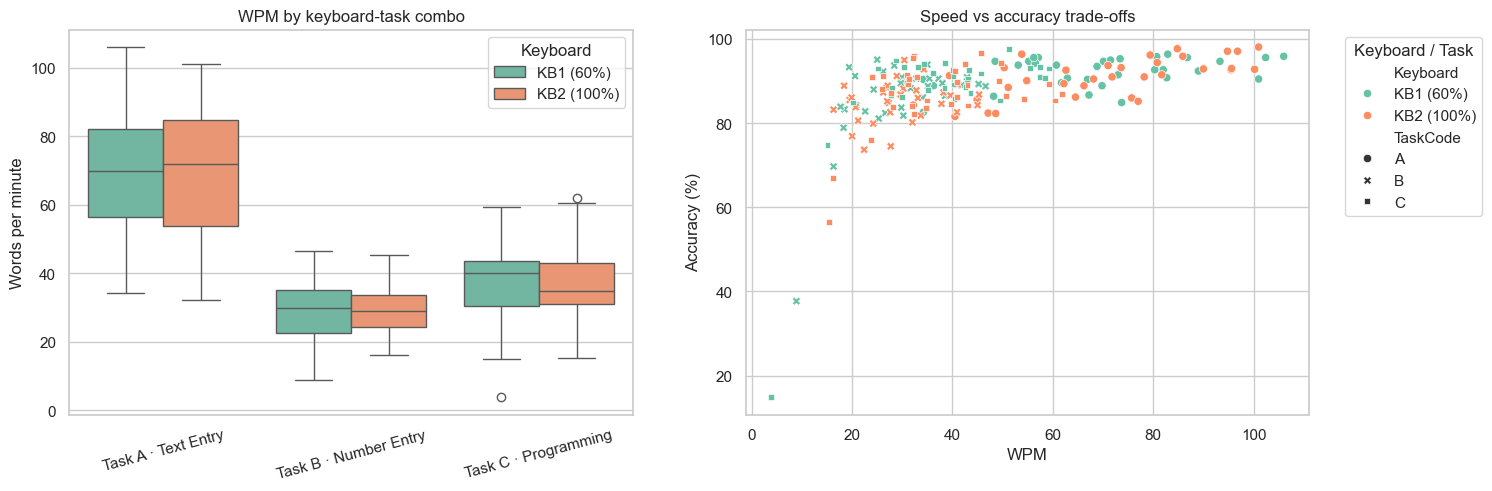

In [306]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=perf_long,
    x="Task",
    y="WPM",
    hue="Keyboard",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("WPM by keyboard-task combo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Words per minute")
axes[0].tick_params(axis='x', rotation=15)

sns.scatterplot(
    data=perf_long,
    x="WPM",
    y="Accuracy",
    hue="Keyboard",
    style="TaskCode",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Speed vs accuracy trade-offs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(title="Keyboard / Task", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Relationship between Typing Performance and NASA-TLX Scores
Note to self: Does this matter?

The graph below shows that higher WPM seems to correlate to lower perceived workload. This could be because people who type faster perceive the task to also be easier.

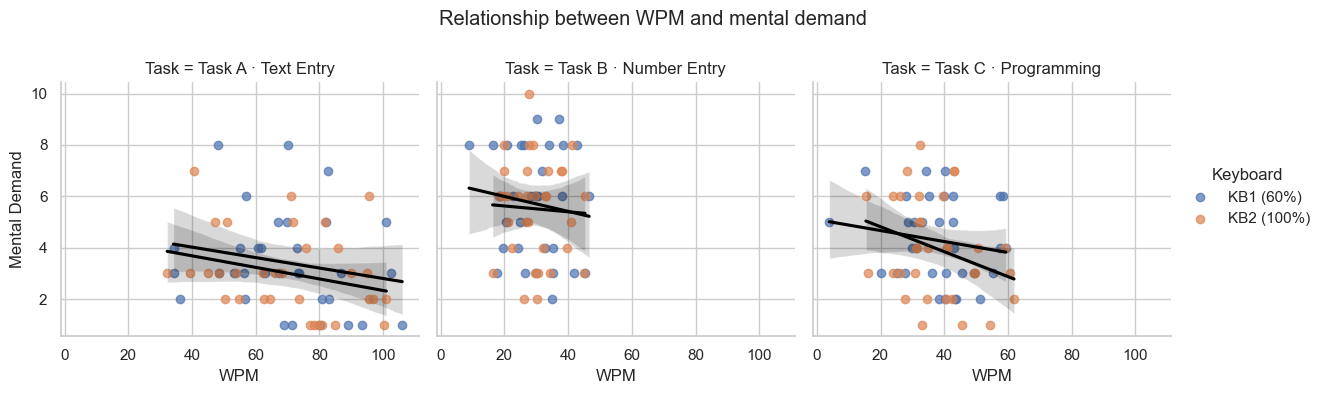

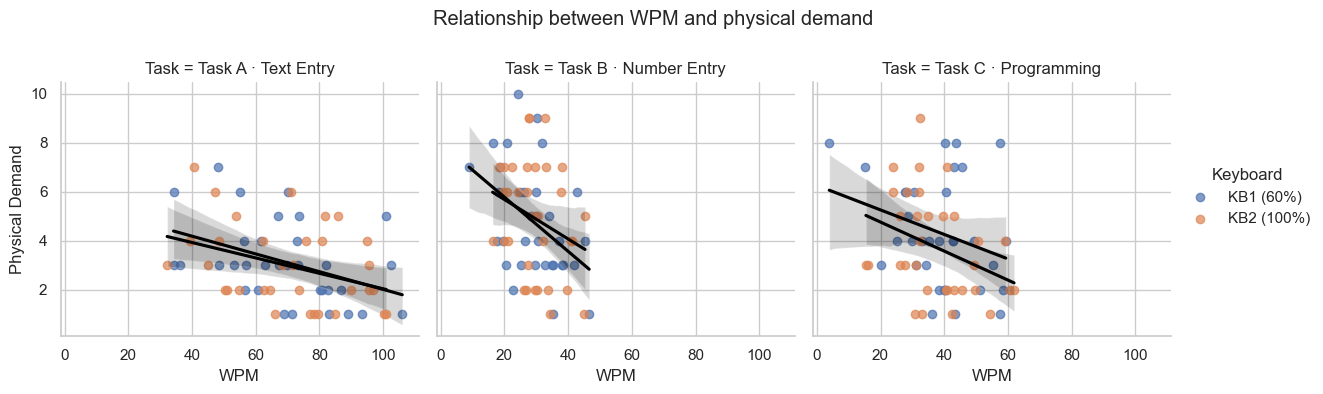

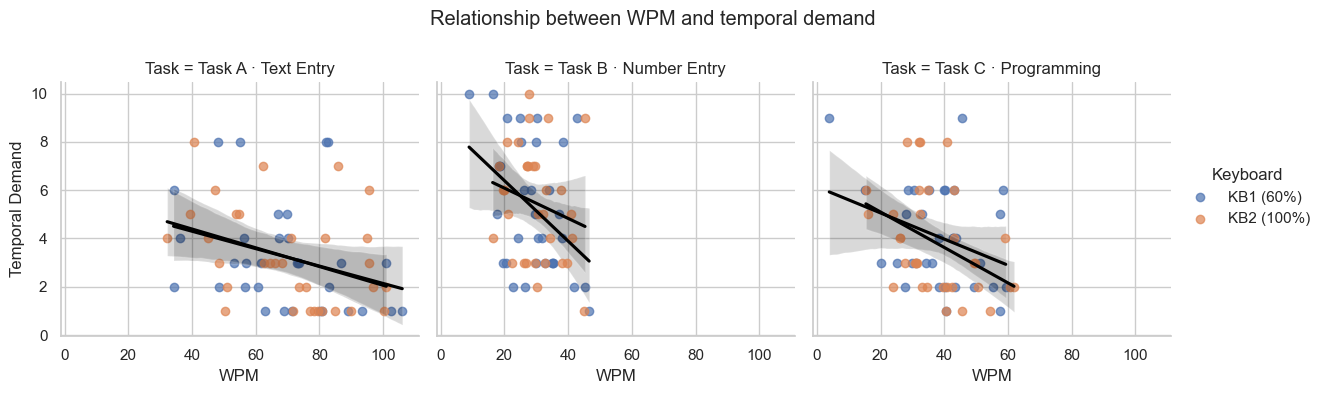

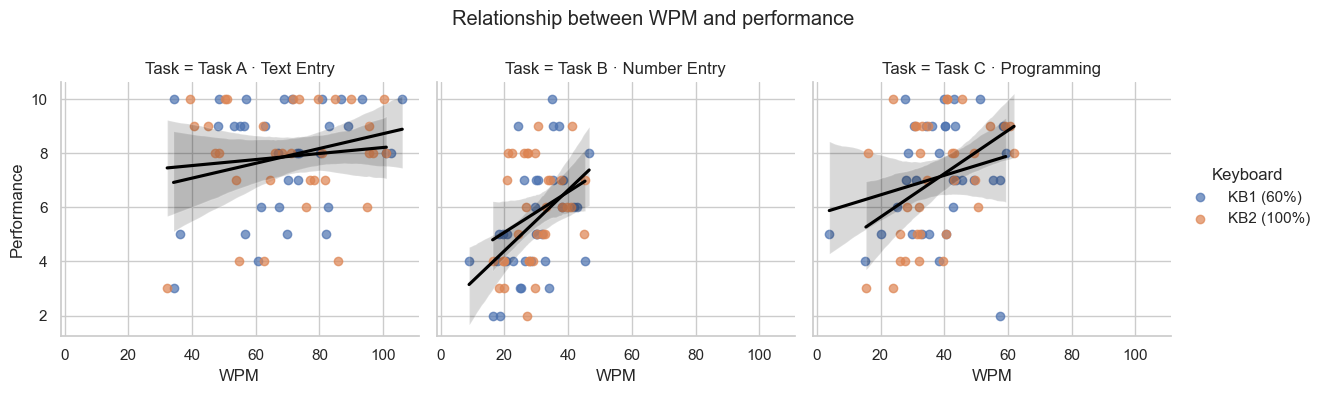

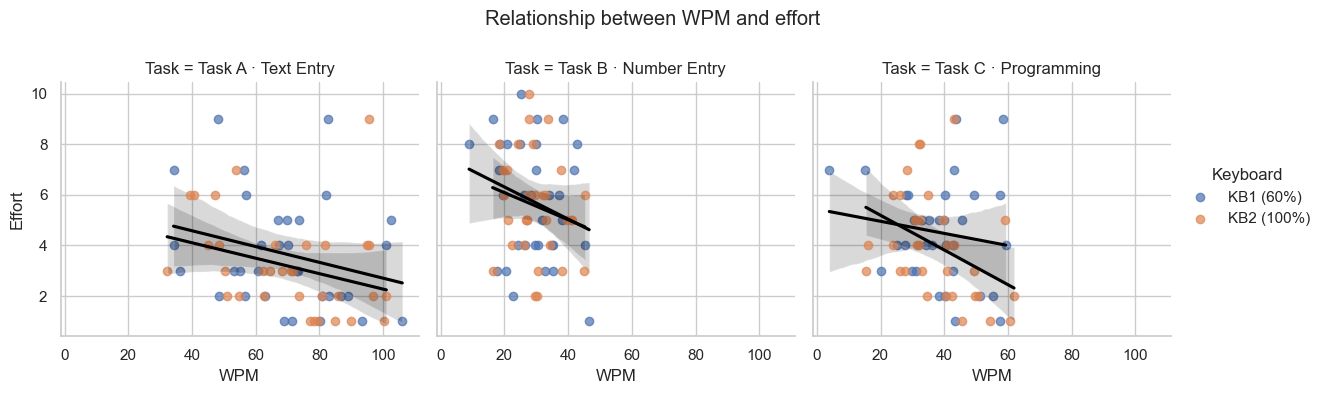

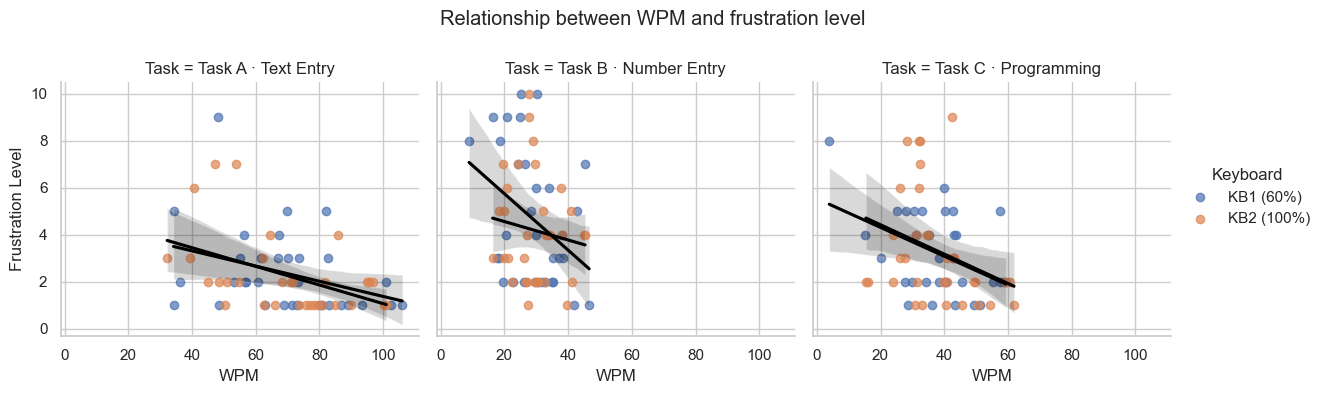

In [307]:
x = "WPM"
for dim in workload_cols:
    g = sns.lmplot(
        data=perf_tlx,
        x=x,
        y=dim,
        hue="Keyboard",
        col="Task",
        height=4,
        aspect=1,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "black"},
    )
    g.figure.subplots_adjust(top=0.8)
    g.figure.suptitle(f"Relationship between {x} and {dim.lower()}")
    plt.show()


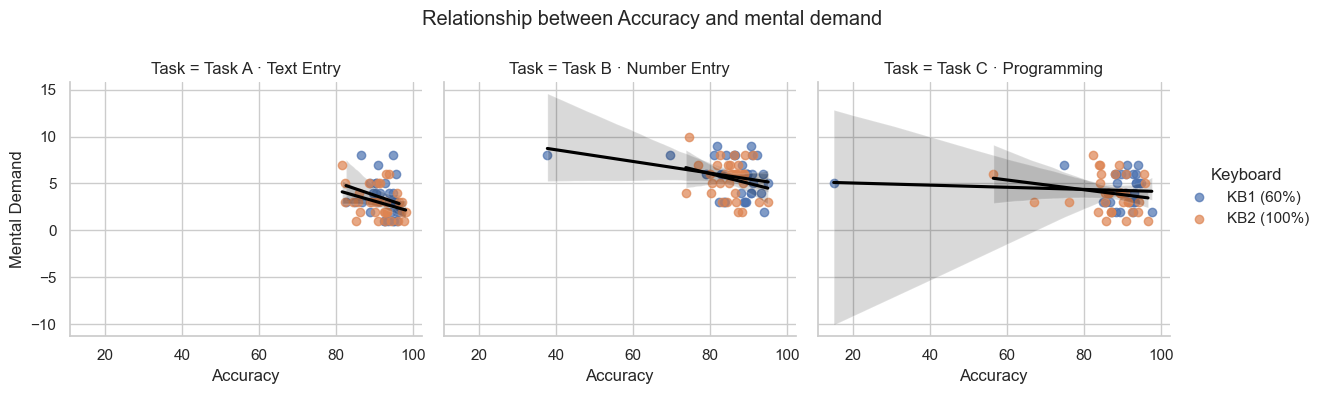

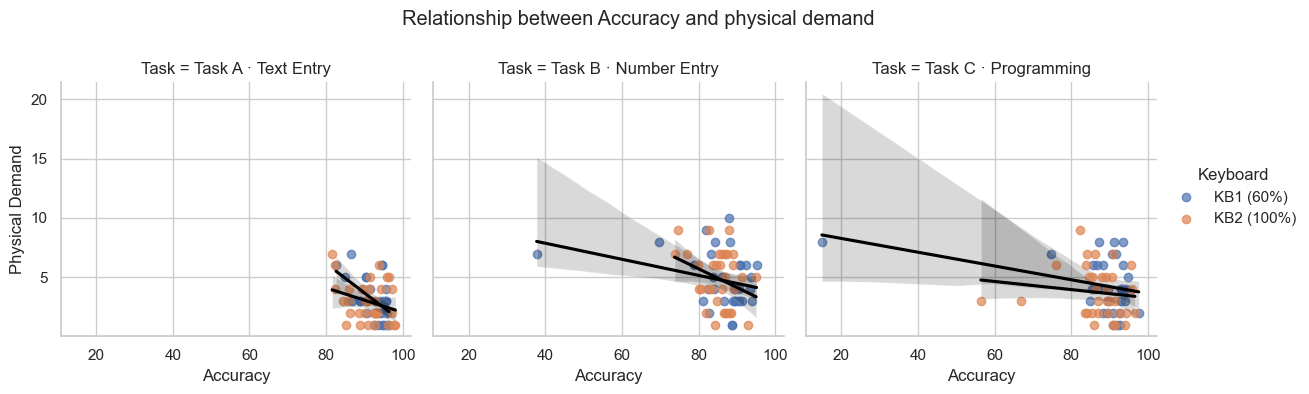

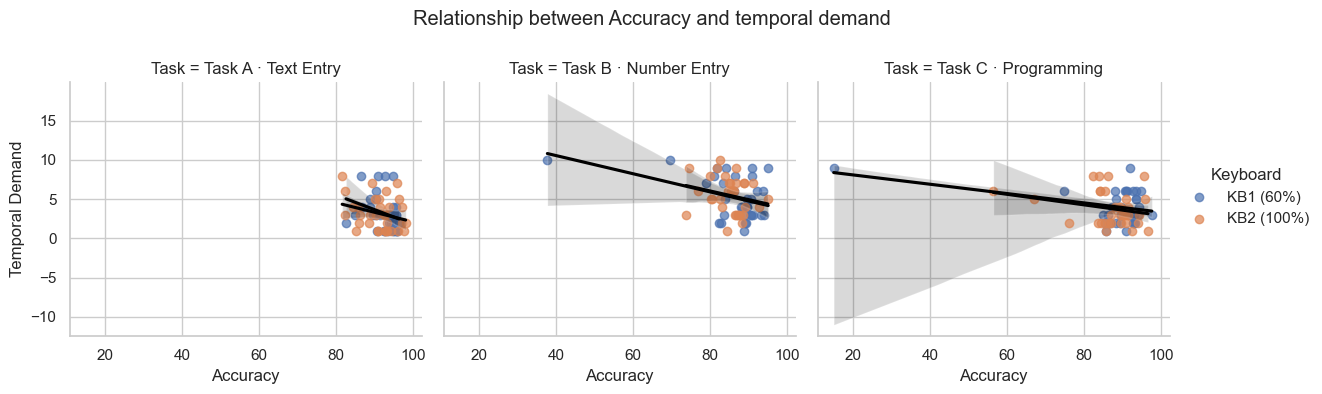

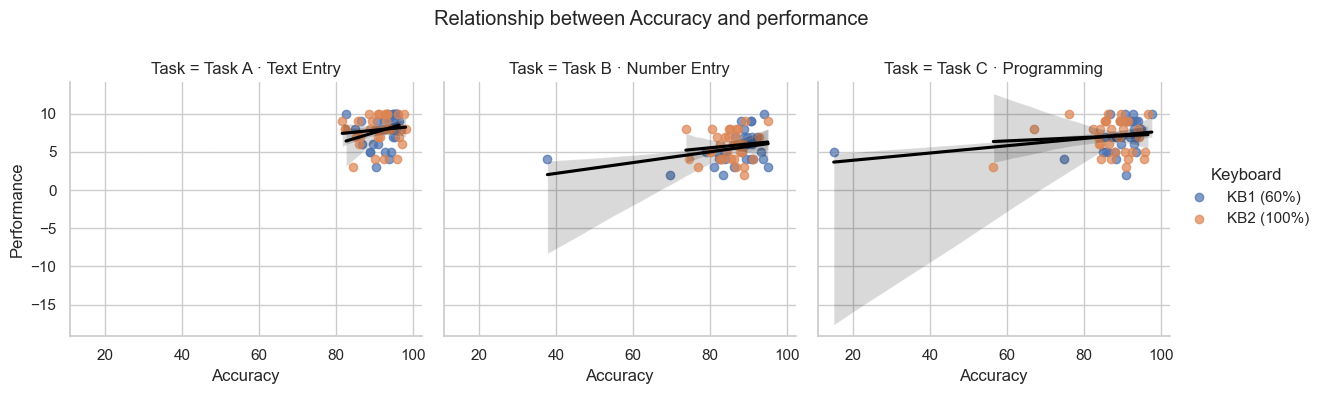

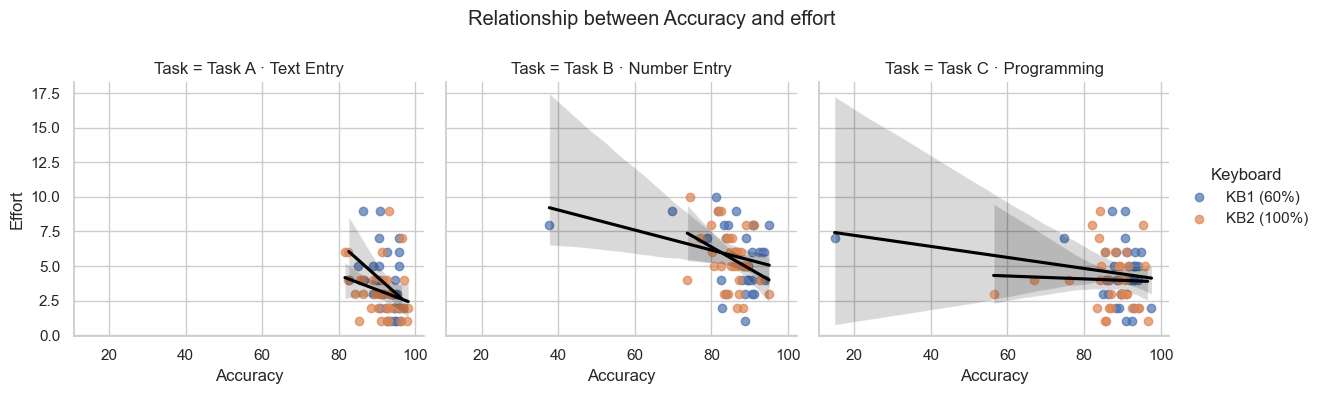

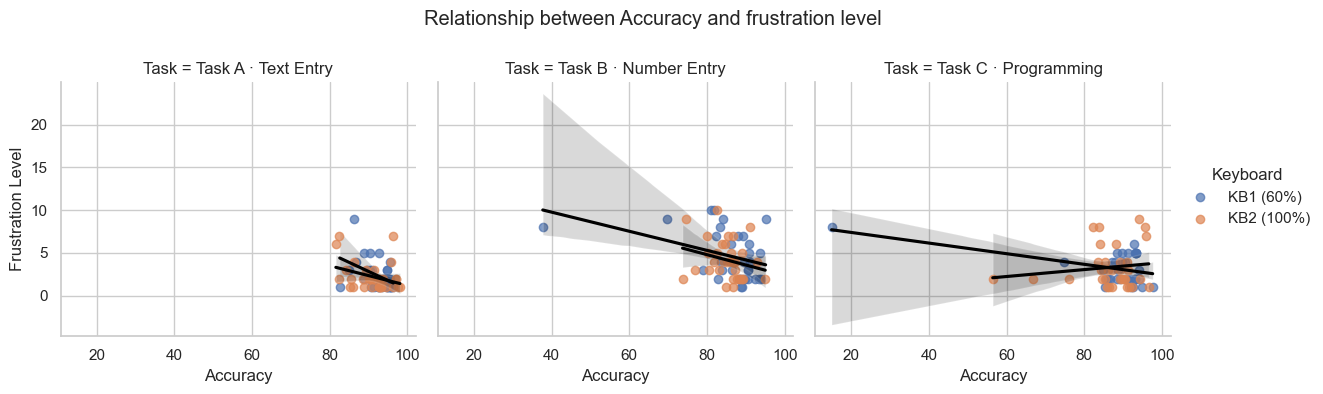

In [308]:
x = "Accuracy"
for dim in workload_cols:
    g = sns.lmplot(
        data=perf_tlx,
        x=x,
        y=dim,
        hue="Keyboard",
        col="Task",
        height=4,
        aspect=1,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "black"},
    )
    g.figure.subplots_adjust(top=0.8)
    g.figure.suptitle(f"Relationship between {x} and {dim.lower()}")
    plt.show()


## TODO: Double check this...
**Key insights**
- Typing speed gaps between keyboards are small (≤1 WPM on average) across all tasks; Text Entry favors KB2 slightly (+1 WPM) while Programming shows a modest KB1 edge (−1 WPM for KB2). Accuracy follows the same minor shifts, reinforcing that keyboard choice alone is not a dominant driver of raw performance.
- Task B · Number Entry is the clear bottleneck regardless of keyboard (≈29 WPM vs 69 WPM on Task A), mirroring the highest error rates (~14%) and the longest completion times (~112 s). Task design, not keyboard size, explains most of the variance.
- NASA TLX composites are consistently highest for Task B (~5.25) and lowest for Task A (~3.8–4.0). KB2 trims perceived workload slightly for the more demanding Programming task (4.31 vs 4.58) but has almost no effect on Number Entry.
- When we merge objective speed with subjective workload, faster typists report lower TLX scores (WPM vs TLX r = −0.44), while error-prone runs align with higher workload (ErrorRate vs TLX r = +0.39). This suggests UX gains may come more from helping participants maintain accuracy than from swapping keyboard form factors.


In [309]:
# Mixed-effects models (fixed DV quoting): PreferenceMatch × TaskCode
# Re-run this cell instead of the earlier mixed-model loop if you hit Patsy
# syntax errors for DVs with spaces (e.g., "Mental Demand").

from collections import defaultdict

mixed_results = {}
mm_marginal_means = {}

for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    model_data = perf_tlx[[
        "Participant_Number",
        "PreferenceMatch",
        "TaskCode",
        dv,
    ]].dropna().copy()

    # Use a safely quoted DV name for Patsy when the column has spaces or
    # characters that are not valid Python identifiers (e.g., "Mental Demand").
    if dv.isidentifier():
        dv_term = dv
    else:
        dv_term = f'Q("{dv}")'

    # Mixed-effects model with random intercept for participant
    # DV ~ PreferenceMatch * TaskCode + (1 | Participant_Number)
    formula_mixed = f"{dv_term} ~ PreferenceMatch * C(TaskCode)"
    md = smf.mixedlm(formula_mixed, data=model_data, groups=model_data["Participant_Number"])
    mdf = md.fit(reml=False, method="lbfgs")

    print("\n" + "=" * 80)
    print(f"Mixed-effects model for {dv}")
    print(mdf.summary())

    # Approximate F-tests and partial eta-squared using type III ANOVA from an OLS model
    # with Participant as a fixed blocking factor. This is equivalent to a random intercept
    # in a balanced design and provides standard F-statistics.
    formula_ols = f"{dv_term} ~ C(PreferenceMatch) * C(TaskCode) + C(Participant_Number)"
    ols_model = smf.ols(formula_ols, data=model_data).fit()
    anova_tbl = anova_lm(ols_model, typ=3)

    # Extract rows of interest
    effect_labels = {
        "C(PreferenceMatch)": "PreferenceMatch",
        "C(TaskCode)": "TaskCode",
        "C(PreferenceMatch):C(TaskCode)": "PreferenceMatch:TaskCode",
    }

    ss_error = anova_tbl.loc["Residual", "sum_sq"]
    dv_results = {}

    for row_label, pretty_label in effect_labels.items():
        if row_label not in anova_tbl.index:
            continue
        row = anova_tbl.loc[row_label]
        f_val = row["F"]
        p_val = row["PR(>F)"]
        df_num = row["df"]
        df_den = anova_tbl.loc["Residual", "df"]
        eta_p = np.nan
        if not np.isnan(f_val):
            ss_effect = row["sum_sq"]
            eta_p = ss_effect / (ss_effect + ss_error) if (ss_effect + ss_error) > 0 else np.nan

        dv_results[pretty_label] = {
            "F": float(f_val) if not np.isnan(f_val) else np.nan,
            "p": float(p_val) if not np.isnan(p_val) else np.nan,
            "df_num": float(df_num),
            "df_den": float(df_den),
            "eta_p2": float(eta_p) if not np.isnan(eta_p) else np.nan,
        }

    # Marginal means for PreferenceMatch (collapsing over TaskCode)
    mm = (
        model_data
        .groupby("PreferenceMatch")[dv]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Mean", "std": "SD", "count": "N"})
    )
    # 95% CI using normal approximation
    mm["SE"] = mm["SD"] / np.sqrt(mm["N"])
    mm["CI_lower"] = mm["Mean"] - 1.96 * mm["SE"]
    mm["CI_upper"] = mm["Mean"] + 1.96 * mm["SE"]

    mixed_results[dv] = dv_results
    mm_marginal_means[dv] = mm

# Convert mixed model results to a tidy table and save
rows = []
for dv, effects in mixed_results.items():
    for effect_name, stats_dict in effects.items():
        rows.append({
            "DV": dv,
            "Effect": effect_name,
            **stats_dict,
        })

mixed_results_df = pd.DataFrame(rows)

os.makedirs("results", exist_ok=True)
mixed_results_df.to_csv("results/mixed_model_results.csv", index=False)

# Also save marginal means
mm_rows = []
for dv, table in mm_marginal_means.items():
    for pref, row in table.iterrows():
        mm_rows.append({
            "DV": dv,
            "PreferenceMatch": int(pref),
            "Mean": row["Mean"],
            "SD": row["SD"],
            "N": int(row["N"]),
            "SE": row["SE"],
            "CI_lower": row["CI_lower"],
            "CI_upper": row["CI_upper"],
        })

mm_df = pd.DataFrame(mm_rows)
mm_df.to_csv("results/marginal_means_preference.csv", index=False)

mixed_results_df.head()



Mixed-effects model for WPM
                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         WPM      
No. Observations:         198             Method:                     ML       
No. Groups:               33              Scale:                      74.2029  
Min. group size:          6               Log-Likelihood:             -745.2822
Max. group size:          6               Converged:                  Yes      
Mean group size:          6.0                                                  
-------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                         68.250    2.256  30.248 0.000  63.827  72.672
C(TaskCode)[T.B]                 -39.289    1.816 -21.635 0.000 -42.848 -35.730
C(TaskCode)[T.C]                

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Mixed-effects model for Mental Demand
                   Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    Q("Mental Demand")
No. Observations:      198        Method:                ML                
No. Groups:            33         Scale:                 1.3895            
Min. group size:       6          Log-Likelihood:        -349.9515         
Max. group size:       6          Converged:             Yes               
Mean group size:       6.0                                                 
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         3.499    0.299 11.721 0.000  2.914  4.084
C(TaskCode)[T.B]                  2.289    0.249  9.211 0.000  1.802  2.776
C(TaskCode)[T.C]                  0.778    0.249  3.130 0.002  0.291

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Mixed-effects model for Frustration Level
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Q("Frustration Level")
No. Observations:    198       Method:               ML                    
No. Groups:          33        Scale:                2.3230                
Min. group size:     6         Log-Likelihood:       -393.7233             
Max. group size:     6         Converged:            Yes                   
Mean group size:     6.0                                                   
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         2.485    0.334  7.442 0.000  1.830  3.139
C(TaskCode)[T.B]                  2.289    0.321  7.124 0.000  1.659  2.919
C(TaskCode)[T.C]                  1.133    0.321  3.527 0.000  0

,DV,Effect,F,p,df_num,df_den,eta_p2
0,WPM,PreferenceMatch,3.149075,7.787166e-02,1.0,160.0,0.019302
1,WPM,TaskCode,249.713127,6.256045e-50,2.0,160.0,0.757365
2,WPM,PreferenceMatch:TaskCode,1.146284,3.204116e-01,2.0,160.0,0.014126
3,Accuracy,PreferenceMatch,0.003858,9.505513e-01,1.0,160.0,0.000024
4,Accuracy,TaskCode,9.405449,1.374295e-04,2.0,160.0,0.105200
